# Equity Markov-Switching Extension - Two Pipelines
## Xavier Jaeger · Bachelor Thesis · Erasmus University Rotterdam

Two fully independent end-to-end pipelines:

| Pipeline | r_total | k Pass 2 | Motivation |
|---|---|---|---|
| **P1** | 12 (MST-comparable) | 6 | Directly comparable to MST hard-threshold |
| **P2** | AH-selected | AH-selected | Data-driven, BM-consistent |

Each pipeline runs its own EM, produces its own xi_bear, and reports its own
pricing results. P1 is the primary (thesis headline) result.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from scipy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
np.random.seed(19780308)

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'font.family': 'serif', 'axes.labelsize': 10,
    'xtick.labelsize': 8, 'ytick.labelsize': 8,
})

PATH_RETURNS = 'Input/mExcess_Returns_Farago_Tedongap_201508_LM.csv'
PATH_ADBEAR  = 'Input/ADBear_Monthly_Formation.csv'
PATH_REGIME  = 'Input/Regime_Analysis_LM_Whole.csv'

# Fixed parameters
R_LAG       = 1
THETA_HAT   = 0.318423      # MST full-sample threshold
N_FACTORS   = 6             # MST number of factors per regime
R_TOTAL     = 12            # MS total factors: r1+r2 = 6+6
EM_MAX_ITER = 500
EM_TOL      = 1e-7
# the global optima seem to be 0.176 and 0.153
EM_OMEGA1    = 0.2   # bull
EM_OMEGA2    = 0.1   # bear



In [2]:

# SHARED HELPER FUNCTIONS


def mst_demean(X, d):
    """MST regime demeaning (NA trick)."""
    X_na = (X * d[:,None]).astype(float)
    X_na[d==0] = np.nan
    mu   = np.nanmean(X_na, axis=0)
    Xdm  = np.nan_to_num(X_na - mu, nan=0.0)
    return Xdm, mu

def mst_pca(Xdm, k, N):
    """B = sqrt(N) * top-k eigenvectors of Xdm'Xdm."""
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm)
    idx = np.argsort(ev)[::-1]
    return np.sqrt(N) * evec[:, idx[:k]]

def mst_gamma(X_ret_full, B, k, T_j):
    """Pass 2 gamma: solve(B'B) B' X' / T_j  (no intercept)."""
    Bk = B[:,:k]
    return (np.linalg.inv(Bk.T@Bk+1e-12*np.eye(k)) @ Bk.T @ X_ret_full.T).sum(1)/T_j

def compute_rmspe(pe, N): return np.sqrt(pe@pe/N)

def compute_adjr2(rmspe_val, R_bar, N, k):
    ss  = R_bar @ R_bar
    r2  = 1 - N*rmspe_val**2/ss if ss!=0 else np.nan
    return 1 - (1-r2)*N/(N-k) if ss!=0 else np.nan

def newey_west_se(x, lags=None):
    T_ = len(x)
    if lags is None: lags = int(np.floor(4*(T_/100)**(2/9)))
    xc = x - x.mean(); s2 = np.dot(xc,xc)/T_
    for l in range(1,lags+1):
        s2 += 2*(1-l/(lags+1))*np.dot(xc[l:],xc[:-l])/T_
    return np.sqrt(max(s2/T_,1e-30))

def fm_tstats(X_ret, w, B, k):
    """Fama-MacBeth t-statistics with NW HAC, using weights w (binary or xi)."""
    BtB_inv  = np.linalg.inv(B[:,:k].T@B[:,:k]+1e-10*np.eye(k))
    gamma_ts = (BtB_inv @ B[:,:k].T @ X_ret.T).T   # T x k
    w_norm   = w / (w.sum()+1e-10)
    gbar     = (w_norm[:,None]*gamma_ts).sum(0)
    se       = np.array([newey_west_se(w*gamma_ts[:,j]) for j in range(k)])
    se       = np.where(se>0, se, 1e-10)
    return gbar, se, gbar/se



In [3]:
# Load data
ret_raw = pd.read_csv(PATH_RETURNS)
adb_raw = pd.read_csv(PATH_ADBEAR)
reg_raw = pd.read_csv(PATH_REGIME)

X_df    = ret_raw.iloc[R_LAG:, 1:].reset_index(drop=True).astype(float)
X       = X_df.values.astype(float)
T, N    = X.shape
dates   = pd.to_datetime(
    ret_raw['Date'].iloc[R_LAG:R_LAG+T].astype(str).reset_index(drop=True),
    format='%Y%m') + pd.offsets.MonthEnd(0)

adb     = adb_raw['ADBearRF_Average_within_the_Month'].values[:T]
rmrf    = reg_raw['RmRf'].values[R_LAG:R_LAG+T]

# Whole-sample demeaning
X_mean  = X.mean(0)
X_dm    = X - X_mean

print(f'Data: T={T}, N={N}')
print(f'Sample: {dates.iloc[0].strftime("%b %Y")} - {dates.iloc[-1].strftime("%b %Y")}')
print(f'ADBear: mean={adb.mean():.4f}, theta={THETA_HAT}')


# A10: Finite-sample caveat
T_over_N = T / N
T_eff_bear_approx = T * 0.33   # approximate bear fraction
print(f'\nFinite-sample diagnostics (BM Assumption A10):')
print(f'  T={T}, N={N},  T/N = {T_over_N:.2f}')
print(f'  BM smallest app: N=49, T=630, T/N=12.9')
print(f'  Approx bear T_eff ~ {T_eff_bear_approx:.0f}')
if T_over_N < 2.0:
    print(f'  [CAUTION] T/N={T_over_N:.2f} < 2.0 - asymptotic results may be imprecise.')
    print(f'  Bear loading estimates particularly noisy: T_eff/N ~ {T_eff_bear_approx/N:.2f}')
else:
    print(f'  T/N ratio acceptable for BM asymptotics.')


Data: T=223, N=130
Sample: Feb 1997 - Aug 2015
ADBear: mean=-0.2867, theta=0.318423

Finite-sample diagnostics (BM Assumption A10):
  T=223, N=130,  T/N = 1.72
  BM smallest app: N=49, T=630, T/N=12.9
  Approx bear T_eff ~ 74
  [CAUTION] T/N=1.72 < 2.0 - asymptotic results may be imprecise.
  Bear loading estimates particularly noisy: T_eff/N ~ 0.57


In [4]:
# Regime dummies
d_D = (adb >= THETA_HAT).astype(float)   # bear
d_S = 1.0 - d_D
T_D = int(d_D.sum()); T_S = int(d_S.sum())
print(f'MST: T_D={T_D} ({T_D/T:.1%} bear), T_S={T_S} ({T_S/T:.1%} bull)')

# Pass 1: PCA
Xdm_D, X_D_mean = mst_demean(X, d_D)
Xdm_S, X_S_mean = mst_demean(X, d_S)

B_D   = mst_pca(Xdm_D, N_FACTORS, N)
B_S   = mst_pca(Xdm_S, N_FACTORS, N)
B_mst = mst_pca(X_dm,  N_FACTORS, N)

# Pass 2: risk premia
gamma_D   = mst_gamma(X*d_D[:,None], B_D, N_FACTORS, T_D)
gamma_S   = mst_gamma(X*d_S[:,None], B_S, N_FACTORS, T_S)
gamma_mst = mst_gamma(X,             B_mst, N_FACTORS, T)

pe_D  = X_D_mean - B_D @ gamma_D
pe_S  = X_S_mean - B_S @ gamma_S

gb_D, se_D, t_D = fm_tstats(X[d_D==1], np.ones(T_D), B_D, N_FACTORS)
gb_S, se_S, t_S = fm_tstats(X[d_S==1], np.ones(T_S), B_S, N_FACTORS)

print(f'\nMST Pass 2 (monthly %):')
print(f'  Bear: gamma_1={gamma_D[0]:.4f}  RMSPE={compute_rmspe(pe_D,N):.4f}%')
print(f'  Bull: gamma_1={gamma_S[0]:.4f}  RMSPE={compute_rmspe(pe_S,N):.4f}%')
print(f'\nADBear stats by regime:')
print(f'  Bear months: ADBear mean={adb[d_D==1].mean():.4f}, RmRf={rmrf[d_D==1].mean():.4f}%')
print(f'  Bull months: ADBear mean={adb[d_S==1].mean():.4f}, RmRf={rmrf[d_S==1].mean():.4f}%')


MST: T_D=56 (25.1% bear), T_S=167 (74.9% bull)

MST Pass 2 (monthly %):
  Bear: gamma_1=-1.6782  RMSPE=0.3400%
  Bull: gamma_1=1.5120  RMSPE=0.1528%

ADBear stats by regime:
  Bear months: ADBear mean=1.2556, RmRf=-1.2414%
  Bull months: ADBear mean=-0.8039, RmRf=1.1050%


In [5]:
# Unconditional fit (the one missing piece)
X_mean_full = X.mean(axis=0)
Xdm_full    = X - X_mean_full

B_unc     = mst_pca(Xdm_full, N_FACTORS, N)
gamma_unc = mst_gamma(X, B_unc, N_FACTORS, T)
F_wm_unc  = X @ B_unc / N

pe_unc_D = X_D_mean - B_unc @ gamma_unc[:N_FACTORS]   # unconditional model's
pe_unc_S = X_S_mean - B_unc @ gamma_unc[:N_FACTORS]   # error on each regime

rmspe_unc_D = compute_rmspe(pe_unc_D, N)
rmspe_unc_S = compute_rmspe(pe_unc_S, N)
rmspe_mst_D = compute_rmspe(pe_D, N)   # already in scope, conditional MST
rmspe_mst_S = compute_rmspe(pe_S, N)

---
## Shared: PCA Linear Representation & AH Factor Selection

In [6]:
def pca_linear_rep(Xdm, r):
    T_, N_ = Xdm.shape
    ev, evec = np.linalg.eigh(Xdm.T @ Xdm / T_)
    idx = np.argsort(ev)[::-1]
    A = np.sqrt(N_) * evec[:, idx[:r]]
    G = Xdm @ A / N_
    return A, G, ev[idx]

def ahn_horenstein_skip1(eigvals, r_max=10):
    """AH (2013) Growth Ratio criterion, skip-first modification.
    Matches BM replication package (main_FamaFrench_FINAL.m).
    r_hat is the TOTAL number of factors r1+r2.
    """
    r_max  = min(r_max, len(eigvals)-3)
    # GR: log(1+lambda_j) / log(1+lambda_{j+1}) - BM uses GR not ER
    ratios = np.log(1 + eigvals[1:r_max+1]) / np.log(1 + eigvals[2:r_max+2])
    r_hat  = int(np.argmax(ratios) + 2)   # +2: skip eig1, ratio array starts at eig2
    return r_hat, ratios

# Full-sample AH selection
S = X_dm.T @ X_dm / T
eigvals_full = np.linalg.eigvalsh(S)[::-1]
r_ah_full, ratios_full = ahn_horenstein_skip1(eigvals_full, r_max=12)
pve_full = eigvals_full[:r_ah_full].sum() / eigvals_full.sum()

print(f'Full-sample AH (skip k=1): r_hat={r_ah_full}')
print(f'Ratios k=2..12: {np.round(ratios_full, 3)}')
print(f'PVE at r_ah={r_ah_full}: {pve_full:.1%}')

R_TOTAL_P1 = 12
# r_ah_full is r_TOTAL per BM: AH selects total factors, BM assumes r1=r2=r_total/2
# Floor: max(r_ah_full, 2) ensures at least 1 factor per regime (BM Assumption 2b)
R_TOTAL_P2 = max(r_ah_full, 2)   # r_total; floor at 2 so r1=r2>=1
K_P1       = N_FACTORS            # = 6
K_P2       = R_TOTAL_P2 // 2     # = 1 (AH-selected per regime)
print(f'Pipeline 1: r_total={R_TOTAL_P1}, k={K_P1}')
print(f'Pipeline 2: r_total={R_TOTAL_P2}, k={K_P2}')

Full-sample AH (skip k=1): r_hat=4
Ratios k=2..12: [1.131 1.043 1.22  1.219 1.06  1.045 1.057 1.04  1.082 1.048 1.017 1.044]
PVE at r_ah=4: 92.5%
Pipeline 1: r_total=12, k=6
Pipeline 2: r_total=4, k=2


---
## Shared: EM Functions

In [7]:
# BLHK forward filter
def blhk_filter(Xdm, G, B1, B2, sig1, sig2, P):
    T_, N_ = Xdm.shape
    p11, p22 = P[0,0], P[1,1]
    denom = 2-p11-p22+1e-12
    xi_prev = np.array([(1-p22)/denom, (1-p11)/denom])
    xi_filt = np.empty((T_,2)); xi_pred = np.empty((T_,2))
    lc = N_ * np.log(2*np.pi)
    for t in range(T_):
        xip = P.T @ xi_prev; xi_pred[t] = xip
        r1t = Xdm[t] - G[t] @ B1.T; r2t = Xdm[t] - G[t] @ B2.T
        ll1 = -0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1))+lc)
        ll2 = -0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2))+lc)
        lm  = max(ll1,ll2)
        eta = np.array([np.exp(ll1-lm), np.exp(ll2-lm)])
        num = eta*xip; s = num.sum()
        xi_filt[t] = num/s if s>1e-300 else xip
        xi_prev = xi_filt[t]
    return xi_filt, xi_pred

# BLHK backward smoother
def blhk_smoother(xi_filt, xi_pred, P):
    T_ = xi_filt.shape[0]
    xi_smooth = np.empty((T_,2)); xi_cross = np.zeros((T_,2,2))
    xi_smooth[-1] = xi_filt[-1]
    for t in range(T_-2,-1,-1):
        sp  = np.where(xi_pred[t+1]>1e-300, xi_pred[t+1], 1e-300)
        raw = xi_filt[t]*(P @ (xi_smooth[t+1]/sp))
        s   = raw.sum(); xi_smooth[t] = raw/s if s>1e-300 else xi_filt[t]
        for j in range(2):
            for k in range(2):
                xi_cross[t+1,j,k] = P[j,k]*xi_filt[t,k]*xi_smooth[t+1,j]/max(xi_pred[t+1,j],1e-300)
        sc = xi_cross[t+1].sum()
        if sc>1e-300: xi_cross[t+1] /= sc
    return xi_smooth, xi_cross

# M-step
def m_step(Xdm, G, xi_smooth, xi_cross, homoskedastic=False):
    T_, N_ = Xdm.shape; r = G.shape[1]
    B_new=[]; sig_new=[]
    for j in range(2):
        w   = xi_smooth[:,j]
        wXG = (Xdm*w[:,None]).T @ G
        wGG = (G*w[:,None]).T @ G + 1e-10*np.eye(r)
        Bj  = wXG @ np.linalg.inv(wGG); B_new.append(Bj)
        res = Xdm - G @ Bj.T
        sig_new.append(np.maximum((w[:,None]*res**2).sum(0)/max(w.sum(),1e-10), 1e-8))
    sum_cross = xi_cross[1:].sum(0); sum_xi = xi_smooth[:-1].sum(0)
    Pnew = np.zeros((2,2))
    for j in range(2):
        for k in range(2):
            Pnew[j,k] = sum_cross[j,k]/max(sum_xi[k],1e-10)
    # A3: homoskedastic option - pool variances across regimes (BM macro application)
    if homoskedastic:
        _w0 = xi_smooth[:,0].sum()
        _w1 = xi_smooth[:,1].sum()
        sig_pooled = (_w0 * sig_new[0] + _w1 * sig_new[1]) / (_w0 + _w1)
        sig_new = [sig_pooled, sig_pooled]
    Pnew = np.clip(Pnew/Pnew.sum(0,keepdims=True), 1e-5, 1-1e-5)
    Pnew /= Pnew.sum(0,keepdims=True)

    return B_new[0], B_new[1], sig_new[0], sig_new[1], Pnew

# Log-likelihood
def log_lik(Xdm, G, B1, B2, sig1, sig2, P):
    T_, N_ = Xdm.shape
    p11,p22 = P[0,0],P[1,1]; d=2-p11-p22+1e-12
    xip = np.array([(1-p22)/d,(1-p11)/d]); ll=0.; lc=N_*np.log(2*np.pi)
    for t in range(T_):
        xip=P.T@xip
        r1t=Xdm[t]-G[t]@B1.T; r2t=Xdm[t]-G[t]@B2.T
        ll1=-0.5*(np.dot(r1t**2,1/sig1)+np.sum(np.log(sig1))+lc)
        ll2=-0.5*(np.dot(r2t**2,1/sig2)+np.sum(np.log(sig2))+lc)
        lm=max(ll1,ll2); e1,e2=np.exp(ll1-lm),np.exp(ll2-lm)
        mix=xip[0]*e1+xip[1]*e2; ll+=np.log(max(mix,1e-300))+lm
        num=np.array([e1*xip[0],e2*xip[1]]); s=num.sum()
        xip=num/s if s>1e-300 else xip
    return ll/(N_*T_)



In [8]:
def run_em_pipeline(X_dm, r_total, label='', rng=None, verbose=True):
    if rng is None:
        rng = np.random.default_rng(19780308)
    A_hat, G_hat, eigvals = pca_linear_rep(X_dm, r_total)
    e_init = X_dm - G_hat @ A_hat.T
    pve = eigvals[:r_total].sum() / eigvals.sum()
    if verbose: print(f'\n[{label}] r_total={r_total}, PVE={pve:.1%}')

    omega_grid = [
        (0.20,0.10),(0.40,0.05),(0.10,0.40),(0.30,0.30),(0.45,0.20),
        (0.15,0.35),(0.35,0.15),(0.25,0.25),(0.40,0.30),(0.10,0.10),
    ]
    
    while len(omega_grid) < 20:
        omega_grid.append((rng.uniform(0.05,0.48), rng.uniform(0.05,0.48)))

    best_ll_ = -np.inf; best_params_ = None
    if verbose: print(f'  {"Start":>5}  {"final_ll":>14}  {"p11":>7}  {"p22":>7}  {"xi2_mean":>9}')
    if verbose: print('  '+'-'*50)

    for s_, (o1, o2) in enumerate(omega_grid):
        B1_=A_hat.copy(); B2_=A_hat.copy()
        s1_=np.maximum(np.var(e_init,0),1e-8); s2_=s1_.copy()
        P_=np.array([[0.5+o1,1-0.5-o1],[1-0.5-o2,0.5+o2]])
        lp_=-np.inf
        for it_ in range(EM_MAX_ITER):
            xf_,xp_=blhk_filter(X_dm,G_hat,B1_,B2_,s1_,s2_,P_)
            xs_,xc_=blhk_smoother(xf_,xp_,P_)
            B1_,B2_,s1_,s2_,P_=m_step(X_dm,G_hat,xs_,xc_)
            ll_=log_lik(X_dm,G_hat,B1_,B2_,s1_,s2_,P_)
            d_=abs(ll_-lp_)/max(0.5*(abs(ll_)+abs(lp_)),1e-10) if it_>0 else 1
            if d_<EM_TOL and it_>5: break
            lp_=ll_
        xs_f_=xs_.copy(); xf_f_=xf_.copy()
        if xs_f_[:,1].mean()>xs_f_[:,0].mean():
            xs_f_=xs_f_[:,[1,0]]; xf_f_=xf_f_[:,[1,0]]
            B1_,B2_=B2_.copy(),B1_.copy()
            s1_,s2_=s2_.copy(),s1_.copy()
            P_=P_[[1,0],:][:,[1,0]]
        if verbose: print(f'  {s_+1:>5}  {ll_:>14.8f}  {P_[0,0]:>7.4f}  {P_[1,1]:>7.4f}  {xs_f_[:,1].mean():>9.4f}')
        if ll_>best_ll_:
            best_ll_=ll_
            best_params_=(B1_.copy(),B2_.copy(),s1_.copy(),s2_.copy(),
                          P_.copy(),xs_f_.copy(),xf_f_.copy())

    B1,B2,sig1,sig2,P,xs_f,xf_f = best_params_
    xi_bear_=xs_f[:,1]; xi_bull_=xs_f[:,0]
    p11_,p22_=P[0,0],P[1,1]
    pi1_=(1-p22_)/(2-p11_-p22_+1e-12)
    if verbose: print(f'\n  Best ll={best_ll_:.6f}')
    print(f'  p11={p11_:.4f}, p22={p22_:.4f}')
    if verbose: print(f'  E[bull]={1/(1-p11_):.1f}m, E[bear]={1/(1-p22_):.1f}m')
    if verbose: print(f'  xi_bear mean={xi_bear_.mean():.4f}')
    if verbose: print(f'  B1/B2 corr={np.corrcoef(B1.flatten(),B2.flatten())[0,1]:.4f}')
    n_int=((xi_bear_>0.05)&(xi_bear_<0.95)).sum()
    if verbose: print(f'  Interior P(bear): {n_int}/{len(xi_bear_)} = {n_int/len(xi_bear_):.1%}')
    return B1,B2,sig1,sig2,P,xi_bear_,xi_bull_,best_ll_,A_hat,G_hat,p11_,p22_


def pipeline_pass2(X, B1, B2, xi_bear, xi_bull, k, N):
    def norm(B,k_):
        cn=np.sqrt((B[:,:k_]**2).sum(0)/N); cn=np.where(cn>1e-10,cn,1.0)
        return B[:,:k_]/cn[None,:]
    B2n=norm(B2,k); B1n=norm(B1,k)
    def p2(X_,Bj,xi_,k_):
        T_eff=xi_.sum(); Rbar=(xi_[:,None]*X_).sum(0)/T_eff
        Bk=Bj[:,:k_]
        gam=np.linalg.inv(Bk.T@Bk+1e-10*np.eye(k_))@Bk.T@Rbar
        alpha=Rbar-Bk@gam
        return gam,alpha,np.sqrt((alpha**2).mean()),Rbar,T_eff
    gD,aD,rD,RD,TeffD=p2(X,B2n,xi_bear,k)
    gS,aS,rS,RS,TeffS=p2(X,B1n,xi_bull,k)
    gbD,seD,tD=fm_tstats(X,xi_bear,B2n,k)
    gbS,seS,tS=fm_tstats(X,xi_bull,B1n,k)
    return dict(B2n=B2n,B1n=B1n,gD=gD,aD=aD,rD=rD,RD=RD,TeffD=TeffD,
                gS=gS,aS=aS,rS=rS,RS=RS,TeffS=TeffS,
                gbD=gbD,tD=tD,gbS=gbS,tS=tS,
                predD=B2n@gD, predS=B1n@gS)


def pipeline_pass3_equity(G_obs, Xdm_D, Xdm_S, B_D, B_S, d_D, d_S,
                          gamma_D, gamma_S, p2, xi_bear, xi_bull, N):
    def p3_ms(G_obs,B_j,xi_j,gam):
        k_=len(gam); T_eff=xi_j.sum()
        G_bar=(xi_j[:,None]*G_obs).sum(0)/T_eff; G_dm=G_obs-G_bar
        Binv=np.linalg.inv(B_j[:,:k_].T@B_j[:,:k_]/N+1e-10*np.eye(k_))
        u=(X_dm@B_j[:,:k_]/N)@Binv.T
        num=(xi_j[:,None]*G_dm).T@u; den=(xi_j[:,None]*u).T@u+1e-10*np.eye(k_)
        Lam=num@np.linalg.inv(den)
        return Lam,float((Lam@gam).item())
    def p3_mst(G_obs,Xdm_j,B_j,d_j,gam):
        G_bar=G_obs[d_j==1].mean(0); G_dm=G_obs-G_bar
        F_j=(Xdm_j@B_j/N)[d_j==1]; u=F_j[:,:len(gam)]
        num=(G_dm[d_j==1]).T@u; den=u.T@u+1e-10*np.eye(len(gam))
        Lam=num@np.linalg.inv(den)
        return Lam,float((Lam@gam).item())
    _,gD_mst=p3_mst(G_obs,Xdm_D,B_D,d_D,gamma_D)
    _,gS_mst=p3_mst(G_obs,Xdm_S,B_S,d_S,gamma_S)
    _,gD_ms =p3_ms(G_obs,p2['B2n'],xi_bear,p2['gD'])
    _,gS_ms =p3_ms(G_obs,p2['B1n'],xi_bull,p2['gS'])
    print(f'  {"Factor":<8}  {"MST Bear":>12}  {"MS Bear":>12}  {"MST Bull":>12}  {"MS Bull":>12}')
    print('  '+'-'*56)
    print(f'  {"RmRf":<8}  {gD_mst*12:>12.3f}%  {gD_ms*12:>12.3f}%  '
          f'{gS_mst*12:>12.3f}%  {gS_ms*12:>12.3f}%')
    return gD_mst,gS_mst,gD_ms,gS_ms


print('Pipeline helpers defined.')

Pipeline helpers defined.


---
# Pipeline 1 - r_total=12, k=6 (MST-Comparable)

Direct apples-to-apples comparison with MST. EM on 12-factor linear representation,
Pass 2/3 at k=6.

In [9]:
(B1_p1,B2_p1,sig1_p1,sig2_p1,P_p1,
 xi_bear_p1,xi_bull_p1,ll_p1,
 A_hat_p1,G_hat_p1,p11_p1,p22_p1) = run_em_pipeline(X_dm,R_TOTAL_P1,'P1 r=12')


[P1 r=12] r_total=12, PVE=96.2%
  Start        final_ll      p11      p22   xi2_mean
  --------------------------------------------------
      1     -1.42702412   0.8842   0.6531     0.2599
      2     -1.42504668   0.8243   0.7351     0.4078
      3     -1.42460066   0.8196   0.7190     0.3990
      4     -1.52038662   0.8000   0.8000     0.5000
      5     -1.43591154   0.8295   0.7469     0.3946
      6     -1.42556341   0.9081   0.7330     0.2688
      7     -1.42556341   0.9081   0.7330     0.2688
      8     -1.52038662   0.7500   0.7500     0.5000
      9     -1.42350614   0.9000   0.7777     0.3229
     10     -1.52038662   0.6000   0.6000     0.5000
     11     -1.42472462   0.8692   0.8301     0.4482
     12     -1.44373999   0.9259   0.8167     0.2735
     13     -1.42601847   0.8644   0.6756     0.3045
     14     -1.42404513   0.9158   0.7318     0.2511
     15     -1.42325440   0.9290   0.7540     0.2376
     16     -1.42380303   0.8495   0.8533     0.4934
     17     -

### Pipeline 1 - BM Assumption Diagnostics

In [10]:
b_corr_p1=np.corrcoef(B1_p1.flatten(),B2_p1.flatten())[0,1]
print(f'A7 [P1] B1/B2 corr={b_corr_p1:.4f}  {"OK" if b_corr_p1<0.95 else "[CAUTION]"}')

print('A9 [P1] Residual cross-sectional correlation:')
for rname,B_r in [('Bull',B1_p1),('Bear',B2_p1)]:
    F_r=X_dm@B_r[:,:K_P1]/N; E_r=X_dm-F_r@B_r[:,:K_P1].T
    R_c=np.corrcoef(E_r.T); np.fill_diagonal(R_c,np.nan)
    mn=np.nanmean(np.abs(R_c)); mx=np.nanmax(np.abs(R_c))
    print(f'  {rname}: mean={mn:.3f}, max={mx:.3f}{"  [CAUTION>0.20]" if mn>0.20 else ""}')

print('A3 [P1] Homoskedastic robustness:')
_B1h=A_hat_p1.copy();_B2h=A_hat_p1.copy()
_s1h=np.maximum(np.var(X_dm-G_hat_p1@A_hat_p1.T,0),1e-8);_s2h=_s1h.copy()
_Ph=np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
_llph=-np.inf
for _it in range(EM_MAX_ITER):
    _xfh,_xph2=blhk_filter(X_dm,G_hat_p1,_B1h,_B2h,_s1h,_s2h,_Ph)
    _xsh,_xch=blhk_smoother(_xfh,_xph2,_Ph)
    _B1h,_B2h,_s1h,_s2h,_Ph=m_step(X_dm,G_hat_p1,_xsh,_xch,homoskedastic=True)
    _llh=log_lik(X_dm,G_hat_p1,_B1h,_B2h,_s1h,_s2h,_Ph)
    if _it>5 and abs(_llh-_llph)/max(0.5*(abs(_llh)+abs(_llph)),1e-10)<EM_TOL: break
    _llph=_llh
if _xsh[:,1].mean()>_xsh[:,0].mean(): _xsh=_xsh[:,[1,0]]
xi_bear_p1_homo=_xsh[:,1]
n_int_h=((xi_bear_p1_homo>0.05)&(xi_bear_p1_homo<0.95)).sum()
n_int_b=((xi_bear_p1>0.05)&(xi_bear_p1<0.95)).sum()
print(f'  Hetero: ll={ll_p1:.4f}, interior={n_int_b}/{T} ({n_int_b/T:.1%})')
print(f'  Homo:   ll={_llh:.4f}, interior={n_int_h}/{T} ({n_int_h/T:.1%})')
print(f'  ll cost: {_llh-ll_p1:.4f}')

A7 [P1] B1/B2 corr=0.7858  OK
A9 [P1] Residual cross-sectional correlation:
  Bull: mean=0.110, max=0.821
  Bear: mean=0.114, max=0.837
A3 [P1] Homoskedastic robustness:
  Hetero: ll=-1.4222, interior=0/223 (0.0%)
  Homo:   ll=-1.4484, interior=9/223 (4.0%)
  ll cost: -0.0262


### Pipeline 1 - Concordance with MST

[P1] DoC=0.7040  FP=0.1166  FN=0.1794  overlap=16
  Bear months: MS=42, MST=56
  Both bear: -28.97%pa
  P1-only bear: 11.47%pa
  MST-only bear: -15.32%pa
  Both bull: 19.36%pa


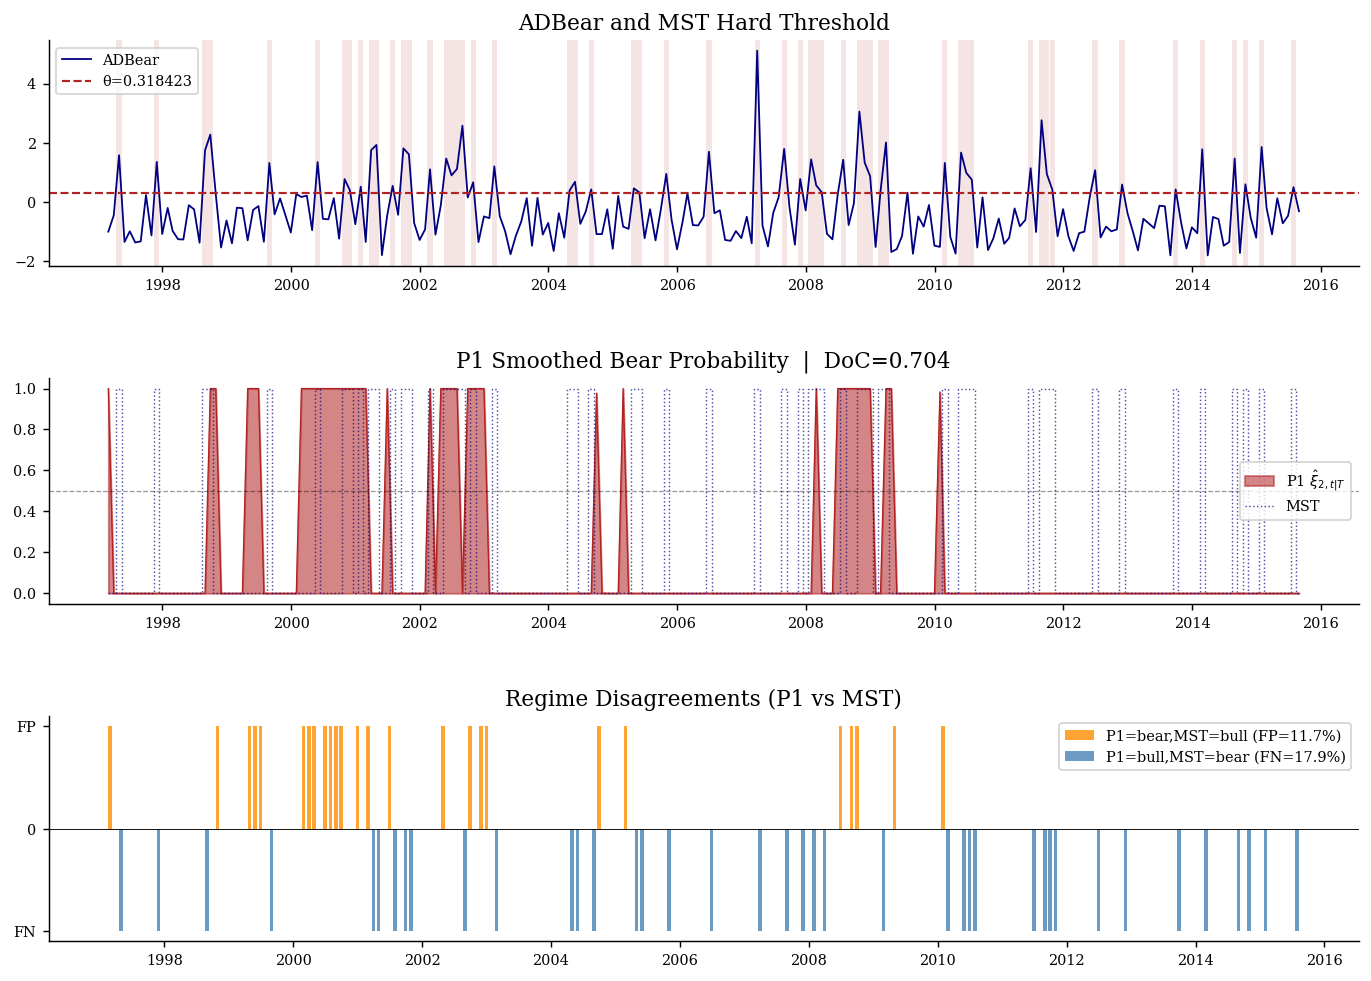

Saved Output/fig_ms_equity_regime_comparison.png


In [11]:
bear_p1=( xi_bear_p1>=0.5).astype(int)
bear_mst=d_D.astype(int)
DoC_p1=(bear_p1*bear_mst+(1-bear_p1)*(1-bear_mst)).mean()
FP_p1=(bear_p1*(1-bear_mst)).mean()
FN_p1=((1-bear_p1)*bear_mst).mean()
overlap_p1=int(((bear_p1==1)&(bear_mst==1)).sum())
print(f'[P1] DoC={DoC_p1:.4f}  FP={FP_p1:.4f}  FN={FN_p1:.4f}  overlap={overlap_p1}')
print(f'  Bear months: MS={bear_p1.sum()}, MST={bear_mst.sum()}')
print(f'  Both bear: {X[((bear_p1==1)&(bear_mst==1))].mean()*12:.2f}%pa')
print(f'  P1-only bear: {X[((bear_p1==1)&(bear_mst==0))].mean()*12:.2f}%pa')
print(f'  MST-only bear: {X[((bear_p1==0)&(bear_mst==1))].mean()*12:.2f}%pa')
print(f'  Both bull: {X[((bear_p1==0)&(bear_mst==0))].mean()*12:.2f}%pa')

# Concordance figure
fig=plt.figure(figsize=(13,9)); gs=GridSpec(3,1,figure=fig,hspace=0.5)
ax1=fig.add_subplot(gs[0])
ax1.plot(dates,adb,color='navy',lw=1.0,label='ADBear')
ax1.axhline(THETA_HAT,color='firebrick',ls='--',lw=1.2,label=f'θ={THETA_HAT}')
for t in range(T):
    if bear_mst[t]:
        ax1.axvspan(dates.iloc[t]-pd.DateOffset(days=15),
                    dates.iloc[t]+pd.DateOffset(days=15),alpha=0.12,color='firebrick',lw=0)
ax1.set_title('ADBear and MST Hard Threshold'); ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax2=fig.add_subplot(gs[1])
ax2.fill_between(dates,xi_bear_p1,alpha=0.55,color='firebrick',label=r'P1 $\hat{\xi}_{2,t|T}$')
ax2.plot(dates,xi_bear_p1,lw=0.7,color='firebrick')
ax2.step(dates,bear_mst,where='mid',color='navy',lw=0.8,ls=':',alpha=0.7,label='MST')
ax2.axhline(0.5,color='black',ls='--',lw=0.7,alpha=0.4); ax2.set_ylim(-0.05,1.05)
ax2.set_title(f'P1 Smoothed Bear Probability  |  DoC={DoC_p1:.3f}'); ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
disagree_fp=(bear_p1==1)&(bear_mst==0); disagree_fn=(bear_p1==0)&(bear_mst==1)
ax3=fig.add_subplot(gs[2])
ax3.bar(dates[disagree_fp],np.ones(disagree_fp.sum()),width=20,color='darkorange',
        alpha=0.8,label=f'P1=bear,MST=bull (FP={FP_p1:.1%})')
ax3.bar(dates[disagree_fn],-np.ones(disagree_fn.sum()),width=20,color='steelblue',
        alpha=0.8,label=f'P1=bull,MST=bear (FN={FN_p1:.1%})')
ax3.axhline(0,color='black',lw=0.5); ax3.set_yticks([-1,0,1]); ax3.set_yticklabels(['FN','0','FP'])
ax3.set_title('Regime Disagreements (P1 vs MST)'); ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator(2))
plt.savefig('Output/fig_ms_equity_regime_comparison.png',bbox_inches='tight'); plt.show()
print('Saved Output/fig_ms_equity_regime_comparison.png')

### Pipeline 1 - Pass 2 (k=6)

In [12]:
p2_p1=pipeline_pass2(X,B1_p1,B2_p1,xi_bear_p1,xi_bull_p1,K_P1,N)
print(f'[P1] RMSPE bear: {p2_p1["rD"]*12:.4f}%pa  (MST: {compute_rmspe(pe_D,N)*12:.4f}%pa)')
print(f'[P1] RMSPE bull: {p2_p1["rS"]*12:.4f}%pa  (MST: {compute_rmspe(pe_S,N)*12:.4f}%pa)')
print(f'\nNW t-statistics [P1, k={K_P1}] (annualised %pa):')
print(f'{"Factor":10}  {"MST Bear":>20}  {"MS Bear":>20}  {"MST Bull":>20}  {"MS Bull":>20}')
print('-'*90)
for j in range(K_P1):
    print(f'gamma_{j+1:<4}  '
          f'{gb_D[j]*12:>8.3f}% [{t_D[j]:>5.2f}]  '
          f'{p2_p1["gbD"][j]*12:>8.3f}% [{p2_p1["tD"][j]:>5.2f}]  '
          f'{gb_S[j]*12:>8.3f}% [{t_S[j]:>5.2f}]  '
          f'{p2_p1["gbS"][j]*12:>8.3f}% [{p2_p1["tS"][j]:>5.2f}]')

[P1] RMSPE bear: 4.6360%pa  (MST: 4.0801%pa)
[P1] RMSPE bull: 1.5523%pa  (MST: 1.8331%pa)

NW t-statistics [P1, k=6] (annualised %pa):
Factor                  MST Bear               MS Bear              MST Bull               MS Bull
------------------------------------------------------------------------------------------
gamma_1      -20.139% [-2.12]    -4.195% [-1.43]    18.144% [ 5.10]    11.451% [ 3.10]
gamma_2        1.760% [ 1.08]    -0.206% [-0.29]    -1.276% [-0.89]    -0.309% [-0.38]
gamma_3       -2.274% [-1.13]     1.041% [ 1.81]    -0.874% [-0.77]     2.889% [ 5.22]
gamma_4        1.647% [ 0.76]    -8.204% [-11.62]     3.381% [ 2.82]     0.364% [ 0.54]
gamma_5       -0.121% [-0.14]     1.553% [ 8.26]     0.789% [ 1.54]    -0.621% [-1.43]
gamma_6        0.246% [ 0.23]     0.228% [ 0.87]     0.270% [ 0.60]     0.341% [ 1.17]


### Pipeline 1 - Pass 3 (RmRf)

In [13]:
G_obs=reg_raw['RmRf'].values[R_LAG:R_LAG+T].reshape(-1,1)
print('Pass 3 rotated risk premia [P1, k=6] (annualised %pa):')
gD_mst_p1,gS_mst_p1,gD_ms_p1,gS_ms_p1=pipeline_pass3_equity(
    G_obs,Xdm_D,Xdm_S,B_D,B_S,d_D,d_S,gamma_D,gamma_S,
    p2_p1,xi_bear_p1,xi_bull_p1,N)

Pass 3 rotated risk premia [P1, k=6] (annualised %pa):
  Factor        MST Bear       MS Bear      MST Bull       MS Bull
  --------------------------------------------------------
  RmRf           -15.378%       -10.054%        13.695%        10.985%


### Pipeline 1 - Pricing Table (k=1..6)

In [14]:
rows_p1=[]
for k in range(1,K_P1+1):
    row={'k':k}
    gDk=mst_gamma(X*d_D[:,None],B_D,k,T_D); peDk=X_D_mean-B_D[:,:k]@gDk
    row['mst_D_rmspe']=compute_rmspe(peDk,N); row['mst_D_adjr2']=compute_adjr2(row['mst_D_rmspe'],X_D_mean,N,k)
    gSk=mst_gamma(X*d_S[:,None],B_S,k,T_S); peSk=X_S_mean-B_S[:,:k]@gSk
    row['mst_S_rmspe']=compute_rmspe(peSk,N); row['mst_S_adjr2']=compute_adjr2(row['mst_S_rmspe'],X_S_mean,N,k)
    p2k=pipeline_pass2(X,B1_p1,B2_p1,xi_bear_p1,xi_bull_p1,k,N)
    row['ms_D_rmspe']=p2k['rD']; row['ms_D_adjr2']=compute_adjr2(p2k['rD'],p2k['RD'],N,k)
    row['ms_S_rmspe']=p2k['rS']; row['ms_S_adjr2']=compute_adjr2(p2k['rS'],p2k['RS'],N,k)
    rows_p1.append(row)
df_p1=pd.DataFrame(rows_p1).set_index('k')
print('PRICING PERFORMANCE [P1, r_total=12]')
print(f'  {"k":>3}  {"MST RMSPE":>11}  {"MS RMSPE":>11}  {"MST AdjR2":>11}  {"MS AdjR2":>11}')
for mc,sc,title in [('mst_D','ms_D','Bear'),('mst_S','ms_S','Bull')]:
    print(f'  {title}:')
    for k,row in df_p1.iterrows():
        print(f'  {k:>3}  {row[mc+"_rmspe"]:>11.4f}  {row[sc+"_rmspe"]:>11.4f}  '
              f'{row[mc+"_adjr2"]:>11.3f}  {row[sc+"_adjr2"]:>11.3f}')

PRICING PERFORMANCE [P1, r_total=12]
    k    MST RMSPE     MS RMSPE    MST AdjR2     MS AdjR2
  Bear:
    1       0.4386       0.8013        0.936        0.151
    2       0.4134       0.8010        0.942        0.145
    3       0.3674       0.7957        0.954        0.149
    4       0.3408       0.4078        0.960        0.775
    5       0.3406       0.3868        0.960        0.796
    6       0.3400       0.3863        0.960        0.795
  Bull:
    1       0.3524       0.2818        0.948        0.919
    2       0.3359       0.2807        0.952        0.919
    3       0.3279       0.1456        0.954        0.978
    4       0.1678       0.1423        0.988        0.979
    5       0.1544       0.1324        0.990        0.982
    6       0.1528       0.1294        0.990        0.982


### Pipeline 1 - Regime Summary Table

In [15]:
res1_p1=X_dm-G_hat_p1[:,:K_P1]@B1_p1[:,:K_P1].T
res2_p1=X_dm-G_hat_p1[:,:K_P1]@B2_p1[:,:K_P1].T
sig1_k_p1=np.maximum(np.var(res1_p1,0),1e-8)
sig2_k_p1=np.maximum(np.var(res2_p1,0),1e-8)
print('='*60)
print('TABLE - EQUITY MS REGIME SUMMARY [P1 r=12 k=6]')
print('='*60)
print(f'  {"Metric":<32}  {"MST":>10}  {"MS":>10}')
print('  '+'-'*56)
bear_p1_=bear_p1
print(f'  {"T_bear":<32}  {T_D:>10}  {bear_p1_.sum():>10}')
print(f'  {"pi_bear":<32}  {T_D/T:>10.3f}  {bear_p1_.mean():>10.3f}')
print(f'  {"Eff T_bear (sum xi)":<32}  {"-":>10}  {xi_bear_p1.sum():>10.1f}')
print(f'  {"E[bear duration] (months)":<32}  {"-":>10}  {1/(1-p22_p1):>10.1f}')
print(f'  {"E[bull duration] (months)":<32}  {"-":>10}  {1/(1-p11_p1):>10.1f}')
print(f'  {"DoC vs MST":<32}  {"-":>10}  {DoC_p1:>10.4f}')
print(f'  {"FP rate":<32}  {"-":>10}  {FP_p1:>10.4f}')
print(f'  {"FN rate":<32}  {"-":>10}  {FN_p1:>10.4f}')
print(f'  {"Overlap months":<32}  {"-":>10}  {overlap_p1:>10}')
print(f'  {"B1/B2 loading correlation":<32}  {"-":>10}  {b_corr_p1:>10.4f}')
print(f'  {"RMSPE bear %pa (k=6)":<32}  {compute_rmspe(pe_D,N)*12:>10.4f}  {p2_p1["rD"]*12:>10.4f}')
print(f'  {"RMSPE bull %pa (k=6)":<32}  {compute_rmspe(pe_S,N)*12:>10.4f}  {p2_p1["rS"]*12:>10.4f}')
print(f'  {"sig2/sig1 (k=6, residuals)":<32}  {"-":>10}  {(sig2_k_p1/sig1_k_p1).mean():>10.4f}')
print(f'  {"sig2/sig1 (EM, full dim)":<32}  {"-":>10}  {(sig2_p1/sig1_p1).mean():>10.4f}')

TABLE - EQUITY MS REGIME SUMMARY [P1 r=12 k=6]
  Metric                                   MST          MS
  --------------------------------------------------------
  T_bear                                    56          42
  pi_bear                                0.251       0.188
  Eff T_bear (sum xi)                        -        42.0
  E[bear duration] (months)                  -         3.0
  E[bull duration] (months)                  -        14.0
  DoC vs MST                                 -      0.7040
  FP rate                                    -      0.1166
  FN rate                                    -      0.1794
  Overlap months                             -          16
  B1/B2 loading correlation                  -      0.7858
  RMSPE bear %pa (k=6)                  4.0801      4.6360
  RMSPE bull %pa (k=6)                  1.8331      1.5523
  sig2/sig1 (k=6, residuals)                 -      1.0449
  sig2/sig1 (EM, full dim)                   -      1.9547


---
# Pipeline 2 - r_total=AH-selected, k=AH-selected (Data-Driven)

BM-consistent specification. EM on AH-selected linear representation,
Pass 2/3 at k=r_ah. xi_bear is genuinely different from Pipeline 1.

In [16]:
(B1_p2,B2_p2,sig1_p2,sig2_p2,P_p2,
 xi_bear_p2,xi_bull_p2,ll_p2,
 A_hat_p2,G_hat_p2,p11_p2,p22_p2) = run_em_pipeline(X_dm,R_TOTAL_P2,f'P2 r={R_TOTAL_P2}')


[P2 r=4] r_total=4, PVE=92.5%
  Start        final_ll      p11      p22   xi2_mean
  --------------------------------------------------
      1     -1.73691363   0.9007   0.7421     0.2778
      2     -1.73445757   0.9210   0.8285     0.3139
      3     -1.73445757   0.9210   0.8285     0.3139
      4     -1.85104343   0.8000   0.8000     0.5000
      5     -1.73412906   0.9088   0.8376     0.3586
      6     -1.73476919   0.9113   0.7848     0.2916
      7     -1.73476919   0.9113   0.7848     0.2916
      8     -1.85104343   0.7500   0.7500     0.5000
      9     -1.73435348   0.9354   0.8502     0.3005
     10     -1.85104343   0.6000   0.6000     0.5000
     11     -1.73384971   0.9116   0.8247     0.3359
     12     -1.73561391   0.8747   0.8072     0.3938
     13     -1.73476919   0.9113   0.7848     0.2916
     14     -1.74687679   0.8910   0.7271     0.2960
     15     -1.74685365   0.8981   0.7383     0.2915
     16     -1.73412906   0.9087   0.8376     0.3586
     17     -1.

### Pipeline 2 - BM Assumption Diagnostics

In [17]:
b_corr_p2=np.corrcoef(B1_p2.flatten(),B2_p2.flatten())[0,1]
print(f'A7 [P2] B1/B2 corr={b_corr_p2:.4f}  {"OK" if b_corr_p2<0.95 else "[CAUTION]"}')
print('A9 [P2] Residual cross-sectional correlation:')
for rname,B_r in [('Bull',B1_p2),('Bear',B2_p2)]:
    F_r=X_dm@B_r[:,:K_P2]/N; E_r=X_dm-F_r@B_r[:,:K_P2].T
    R_c=np.corrcoef(E_r.T); np.fill_diagonal(R_c,np.nan)
    mn=np.nanmean(np.abs(R_c)); mx=np.nanmax(np.abs(R_c))
    print(f'  {rname}: mean={mn:.3f}, max={mx:.3f}')
print('A3 [P2] Homoskedastic robustness:')
_B1h2=A_hat_p2.copy();_B2h2=A_hat_p2.copy()
_s1h2=np.maximum(np.var(X_dm-G_hat_p2@A_hat_p2.T,0),1e-8);_s2h2=_s1h2.copy()
_Ph2=np.array([[0.5+EM_OMEGA1,1-0.5-EM_OMEGA1],[1-0.5-EM_OMEGA2,0.5+EM_OMEGA2]])
_llph2=-np.inf
for _it in range(EM_MAX_ITER):
    _xfh2,_xph22=blhk_filter(X_dm,G_hat_p2,_B1h2,_B2h2,_s1h2,_s2h2,_Ph2)
    _xsh2,_xch2=blhk_smoother(_xfh2,_xph22,_Ph2)
    _B1h2,_B2h2,_s1h2,_s2h2,_Ph2=m_step(X_dm,G_hat_p2,_xsh2,_xch2,homoskedastic=True)
    _llh2=log_lik(X_dm,G_hat_p2,_B1h2,_B2h2,_s1h2,_s2h2,_Ph2)
    if _it>5 and abs(_llh2-_llph2)/max(0.5*(abs(_llh2)+abs(_llph2)),1e-10)<EM_TOL: break
    _llph2=_llh2
if _xsh2[:,1].mean()>_xsh2[:,0].mean(): _xsh2=_xsh2[:,[1,0]]
xi_bear_p2_homo=_xsh2[:,1]
n_int_h2=((xi_bear_p2_homo>0.05)&(xi_bear_p2_homo<0.95)).sum()
n_int_b2=((xi_bear_p2>0.05)&(xi_bear_p2<0.95)).sum()
print(f'  Hetero: ll={ll_p2:.4f}, interior={n_int_b2}/{T} ({n_int_b2/T:.1%})')
print(f'  Homo:   ll={_llh2:.4f}, interior={n_int_h2}/{T} ({n_int_h2/T:.1%})')
print(f'  ll cost: {_llh2-ll_p2:.4f}')

A7 [P2] B1/B2 corr=0.9471  OK
A9 [P2] Residual cross-sectional correlation:
  Bull: mean=0.231, max=0.919
  Bear: mean=0.236, max=0.943
A3 [P2] Homoskedastic robustness:
  Hetero: ll=-1.7338, interior=1/223 (0.4%)
  Homo:   ll=-1.7945, interior=33/223 (14.8%)
  ll cost: -0.0607


### Pipeline 2 - Concordance with MST

In [18]:
bear_p2=(xi_bear_p2>=0.5).astype(int)
DoC_p2=(bear_p2*bear_mst+(1-bear_p2)*(1-bear_mst)).mean()
FP_p2=(bear_p2*(1-bear_mst)).mean()
FN_p2=((1-bear_p2)*bear_mst).mean()
overlap_p2=int(((bear_p2==1)&(bear_mst==1)).sum())
print(f'[P2] DoC={DoC_p2:.4f}  FP={FP_p2:.4f}  FN={FN_p2:.4f}  overlap={overlap_p2}')
print(f'  Both bear: {X[((bear_p2==1)&(bear_mst==1))].mean()*12:.2f}%pa')
print(f'  P2-only bear: {X[((bear_p2==1)&(bear_mst==0))].mean()*12:.2f}%pa')
print(f'  MST-only bear: {X[((bear_p2==0)&(bear_mst==1))].mean()*12:.2f}%pa')

[P2] DoC=0.6547  FP=0.2152  FN=0.1300  overlap=27
  Both bear: -26.58%pa
  P2-only bear: 22.46%pa
  MST-only bear: -12.38%pa


### Pipeline 2 - Pass 2 (k=AH)

In [19]:
p2_p2=pipeline_pass2(X,B1_p2,B2_p2,xi_bear_p2,xi_bull_p2,K_P2,N)
print(f'[P2] RMSPE bear: {p2_p2["rD"]*12:.4f}%pa  (MST: {compute_rmspe(pe_D,N)*12:.4f}%pa)')
print(f'[P2] RMSPE bull: {p2_p2["rS"]*12:.4f}%pa  (MST: {compute_rmspe(pe_S,N)*12:.4f}%pa)')
print(f'\nNW t-statistics [P2, k={K_P2}] (annualised %pa):')
print(f'{"Factor":10}  {"MST Bear":>20}  {"MS Bear":>20}  {"MST Bull":>20}  {"MS Bull":>20}')
print('-'*90)
for j in range(K_P2):
    print(f'gamma_{j+1:<4}  '
          f'{gb_D[j]*12:>8.3f}% [{t_D[j]:>5.2f}]  '
          f'{p2_p2["gbD"][j]*12:>8.3f}% [{p2_p2["tD"][j]:>5.2f}]  '
          f'{gb_S[j]*12:>8.3f}% [{t_S[j]:>5.2f}]  '
          f'{p2_p2["gbS"][j]*12:>8.3f}% [{p2_p2["tS"][j]:>5.2f}]')

[P2] RMSPE bear: 4.0953%pa  (MST: 4.0801%pa)
[P2] RMSPE bull: 3.9471%pa  (MST: 1.8331%pa)

NW t-statistics [P2, k=2] (annualised %pa):
Factor                  MST Bear               MS Bear              MST Bull               MS Bull
------------------------------------------------------------------------------------------
gamma_1      -20.139% [-2.12]     5.012% [ 1.46]    18.144% [ 5.10]    10.276% [ 3.45]
gamma_2        1.760% [ 1.08]    -2.527% [-2.51]    -1.276% [-0.89]     0.792% [ 1.49]


### Pipeline 2 - Pass 3 (RmRf)

In [20]:
print(f'Pass 3 rotated risk premia [P2, k={K_P2}] (annualised %pa):')
gD_mst_p2,gS_mst_p2,gD_ms_p2,gS_ms_p2=pipeline_pass3_equity(
    G_obs,Xdm_D,Xdm_S,B_D,B_S,d_D,d_S,gamma_D,gamma_S,
    p2_p2,xi_bear_p2,xi_bull_p2,N)

Pass 3 rotated risk premia [P2, k=2] (annualised %pa):
  Factor        MST Bear       MS Bear      MST Bull       MS Bull
  --------------------------------------------------------
  RmRf           -15.378%         3.351%        13.695%         9.190%


### Pipeline 2 - Pricing Table

In [21]:
rows_p2=[]
for k in range(1,K_P2+1):
    row={'k':k}
    gDk=mst_gamma(X*d_D[:,None],B_D,k,T_D); peDk=X_D_mean-B_D[:,:k]@gDk
    row['mst_D_rmspe']=compute_rmspe(peDk,N); row['mst_D_adjr2']=compute_adjr2(row['mst_D_rmspe'],X_D_mean,N,k)
    gSk=mst_gamma(X*d_S[:,None],B_S,k,T_S); peSk=X_S_mean-B_S[:,:k]@gSk
    row['mst_S_rmspe']=compute_rmspe(peSk,N); row['mst_S_adjr2']=compute_adjr2(row['mst_S_rmspe'],X_S_mean,N,k)
    p2k=pipeline_pass2(X,B1_p2,B2_p2,xi_bear_p2,xi_bull_p2,k,N)
    row['ms_D_rmspe']=p2k['rD']; row['ms_D_adjr2']=compute_adjr2(p2k['rD'],p2k['RD'],N,k)
    row['ms_S_rmspe']=p2k['rS']; row['ms_S_adjr2']=compute_adjr2(p2k['rS'],p2k['RS'],N,k)
    rows_p2.append(row)
df_p2=pd.DataFrame(rows_p2).set_index('k')
print(f'PRICING PERFORMANCE [P2, r_total={R_TOTAL_P2}]')
print(f'  {"k":>3}  {"MST RMSPE":>11}  {"MS RMSPE":>11}  {"MST AdjR2":>11}  {"MS AdjR2":>11}')
for mc,sc,title in [('mst_D','ms_D','Bear'),('mst_S','ms_S','Bull')]:
    print(f'  {title}:')
    for k,row in df_p2.iterrows():
        print(f'  {k:>3}  {row[mc+"_rmspe"]:>11.4f}  {row[sc+"_rmspe"]:>11.4f}  '
              f'{row[mc+"_adjr2"]:>11.3f}  {row[sc+"_adjr2"]:>11.3f}')

PRICING PERFORMANCE [P2, r_total=4]
    k    MST RMSPE     MS RMSPE    MST AdjR2     MS AdjR2
  Bear:
    1       0.4386       0.4010        0.936        0.517
    2       0.4134       0.3413        0.942        0.647
  Bull:
    1       0.3524       0.3355        0.948        0.866
    2       0.3359       0.3289        0.952        0.870


### Pipeline 2 - Regime Summary Table

In [22]:
res1_p2=X_dm-G_hat_p2[:,:K_P2]@B1_p2[:,:K_P2].T
res2_p2=X_dm-G_hat_p2[:,:K_P2]@B2_p2[:,:K_P2].T
sig1_k_p2=np.maximum(np.var(res1_p2,0),1e-8)
sig2_k_p2=np.maximum(np.var(res2_p2,0),1e-8)
b_corr_p2_=np.corrcoef(B1_p2.flatten(),B2_p2.flatten())[0,1]
print('='*60)
print(f'TABLE - EQUITY MS REGIME SUMMARY [P2 r={R_TOTAL_P2} k={K_P2}]')
print('='*60)
print(f'  {"Metric":<32}  {"MST":>10}  {"MS":>10}')
print('  '+'-'*56)
print(f'  {"T_bear":<32}  {T_D:>10}  {bear_p2.sum():>10}')
print(f'  {"pi_bear":<32}  {T_D/T:>10.3f}  {bear_p2.mean():>10.3f}')
print(f'  {"Eff T_bear (sum xi)":<32}  {"-":>10}  {xi_bear_p2.sum():>10.1f}')
print(f'  {"E[bear duration] (months)":<32}  {"-":>10}  {1/(1-p22_p2):>10.1f}')
print(f'  {"E[bull duration] (months)":<32}  {"-":>10}  {1/(1-p11_p2):>10.1f}')
print(f'  {"DoC vs MST":<32}  {"-":>10}  {DoC_p2:>10.4f}')
print(f'  {"FP rate":<32}  {"-":>10}  {FP_p2:>10.4f}')
print(f'  {"FN rate":<32}  {"-":>10}  {FN_p2:>10.4f}')
print(f'  {"Overlap months":<32}  {"-":>10}  {overlap_p2:>10}')
print(f'  {"B1/B2 loading correlation":<32}  {"-":>10}  {b_corr_p2_:>10.4f}')
print(f'  {"RMSPE bear %pa":<32}  {compute_rmspe(pe_D,N)*12:>10.4f}  {p2_p2["rD"]*12:>10.4f}')
print(f'  {"RMSPE bull %pa":<32}  {compute_rmspe(pe_S,N)*12:>10.4f}  {p2_p2["rS"]*12:>10.4f}')
print(f'  {"sig2/sig1 (k, residuals)":<32}  {"-":>10}  {(sig2_k_p2/sig1_k_p2).mean():>10.4f}')
print(f'  {"sig2/sig1 (EM, full dim)":<32}  {"-":>10}  {(sig2_p2/sig1_p2).mean():>10.4f}')

TABLE - EQUITY MS REGIME SUMMARY [P2 r=4 k=2]
  Metric                                   MST          MS
  --------------------------------------------------------
  T_bear                                    56          75
  pi_bear                                0.251       0.336
  Eff T_bear (sum xi)                        -        74.9
  E[bear duration] (months)                  -         5.7
  E[bull duration] (months)                  -        11.3
  DoC vs MST                                 -      0.6547
  FP rate                                    -      0.2152
  FN rate                                    -      0.1300
  Overlap months                             -          27
  B1/B2 loading correlation                  -      0.9471
  RMSPE bear %pa                        4.0801      4.0953
  RMSPE bull %pa                        1.8331      3.9471
  sig2/sig1 (k, residuals)                   -      0.9409
  sig2/sig1 (EM, full dim)                   -      3.5910


---
# Cross-Pipeline Comparison

In [23]:
DoC_p1p2=(bear_p1*bear_p2+(1-bear_p1)*(1-bear_p2)).mean()
FP_p1p2=(bear_p1*(1-bear_p2)).mean()
FN_p1p2=((1-bear_p1)*bear_p2).mean()
ov_p1p2=int(((bear_p1==1)&(bear_p2==1)).sum())
print('='*65)
print('CROSS-PIPELINE CONCORDANCE (P1 r=12 vs P2 r=AH)')
print('='*65)
print(f'  DoC(P1,P2)={DoC_p1p2:.4f}  FP={FP_p1p2:.4f}  FN={FN_p1p2:.4f}')
print(f'  Joint bear months: {ov_p1p2}')
print()
print('Mean returns by classification:')
for mask,label in [
    ((bear_p1==1)&(bear_p2==1),'Both bear'),
    ((bear_p1==1)&(bear_p2==0),'P1-only bear'),
    ((bear_p1==0)&(bear_p2==1),'P2-only bear'),
    ((bear_p1==0)&(bear_p2==0),'Both bull'),
]:
    if mask.sum()>0:
        print(f'  {label:<20}: {X[mask].mean()*12:.2f}%pa ({mask.sum()} months)')
print()
print(f'  {"":30}  {"P1 (r=12,k=6)":>16}  {"P2 (r=AH,k=AH)":>16}  {"MST":>10}')
print('  '+'-'*76)
print(f'  {"RMSPE bear %pa":30}  '
      f'{p2_p1["rD"]*12:>16.4f}  '
      f'{p2_p2["rD"]*12:>16.4f}  '
      f'{compute_rmspe(pe_D,N)*12:>10.4f}')
print(f'  {"RMSPE bull %pa":30}  '
      f'{p2_p1["rS"]*12:>16.4f}  '
      f'{p2_p2["rS"]*12:>16.4f}  '
      f'{compute_rmspe(pe_S,N)*12:>10.4f}')
print(f'  {"DoC vs MST":30}  '
      f'{DoC_p1:>16.4f}  '
      f'{DoC_p2:>16.4f}  '
      f'{"1.0000":>10}')
print(f'  {"DoC(P1,P2)":30}  '
      f'{DoC_p1p2:>16.4f}')


CROSS-PIPELINE CONCORDANCE (P1 r=12 vs P2 r=AH)
  DoC(P1,P2)=0.7982  FP=0.0269  FN=0.1749
  Joint bear months: 36

Mean returns by classification:
  Both bear           : -0.75%pa (36 months)
  P1-only bear        : -23.06%pa (6 months)
  P2-only bear        : 9.93%pa (39 months)
  Both bull           : 12.18%pa (142 months)

                                     P1 (r=12,k=6)    P2 (r=AH,k=AH)         MST
  ----------------------------------------------------------------------------
  RMSPE bear %pa                            4.6360            4.0953      4.0801
  RMSPE bull %pa                            1.5523            3.9471      1.8331
  DoC vs MST                                0.7040            0.6547      1.0000
  DoC(P1,P2)                                0.7982


---
# Comprehensive Analysis

P1 (r_total=12, k=6) is the primary pipeline for all figures.

In [24]:
from matplotlib.patches import Patch
C_MST,C_P1,C_P2,C_OIL='#4A6FA5','#B23A48','#2CA02C','#D98C2B'
C_BOTH,C_P1ONLY='#8B0000','#FF8C00'

crisis_windows=[
    ('2000-03','2002-10','Dot-com bust\n2000-02'),
    ('2007-12','2009-06','Global financial\ncrisis 2008-09'),
]

kk_p1=df_p1.index.values; kk_p2=df_p2.index.values
mst_bear_rmspe=(df_p1['mst_D_rmspe']).values
p1_bear_rmspe=(df_p1['ms_D_rmspe']).values
mst_bull_rmspe=(df_p1['mst_S_rmspe']).values
p1_bull_rmspe=(df_p1['ms_S_rmspe']).values
mst_bear_r2=df_p1['mst_D_adjr2'].values
p1_bear_r2=df_p1['ms_D_adjr2'].values
mst_bull_r2=df_p1['mst_S_adjr2'].values
p1_bull_r2=df_p1['ms_S_adjr2'].values
p2_bear_rmspe=(df_p2['ms_D_rmspe']).values
p2_bull_rmspe=(df_p2['ms_S_rmspe']).values
p2_bear_r2=df_p2['ms_D_adjr2'].values
p2_bull_r2=df_p2['ms_S_adjr2'].values
print('Figure setup complete.')

Figure setup complete.


---
## Regime Narrative - Episode Dating

In [25]:
in_bear_p1=bear_p1; in_bear_p2=bear_p2
episodes_p1=[]; start=None
for t in range(T):
    if in_bear_p1[t]==1 and start is None: start=t
    elif in_bear_p1[t]==0 and start is not None:
        episodes_p1.append((start,t-1)); start=None
if start is not None: episodes_p1.append((start,T-1))

print('='*70)
print('P1 BEAR EPISODES (xi_bear_p1 >= 0.5)')
print('='*70)
print(f'{"Start":>10}  {"End":>10}  {"Months":>7}  {"Peak xi":>8}  {"Mean ret %pa":>12}')
print('-'*55)
for s,e in episodes_p1:
    span=dates.iloc[s:e+1]
    peak=xi_bear_p1[s:e+1].max()
    ret=X[s:e+1].mean()*12
    print(f'{span.iloc[0].strftime("%Y-%m"):>10}  {span.iloc[-1].strftime("%Y-%m"):>10}  '
          f'{e-s+1:>7}  {peak:>8.3f}  {ret:>12.2f}')

print(f'\nKnown recession/crisis coverage [P1]:')
print(f'{"Episode":40}  {"P1 cover":>10}  {"P2 cover":>10}  {"MST cover":>10}')
print('='*75)
for cs,ce,label in crisis_windows:
    cs_d=pd.Timestamp(cs)+pd.offsets.MonthEnd(0)
    ce_d=pd.Timestamp(ce)+pd.offsets.MonthEnd(0)
    mask=(dates>=cs_d)&(dates<=ce_d)
    if mask.sum()==0: continue
    p1c=in_bear_p1[mask].mean()*100
    p2c=in_bear_p2[mask].mean()*100
    mc=bear_mst[mask].mean()*100
    print(f'  {label[:38]:<38}  {p1c:>9.0f}%  {p2c:>9.0f}%  {mc:>9.0f}%')

P1 BEAR EPISODES (xi_bear_p1 >= 0.5)
     Start         End   Months   Peak xi  Mean ret %pa
-------------------------------------------------------
   1997-02     1997-02        1     1.000        -13.72
   1998-09     1998-10        2     1.000         67.13
   1999-04     1999-06        3     1.000         54.35
   2000-02     2001-02       13     1.000          1.95
   2001-06     2001-06        1     1.000         12.54
   2002-02     2002-02        1     1.000        -28.76
   2002-04     2002-07        4     1.000        -64.46
   2002-09     2002-12        4     1.000         -3.05
   2004-09     2004-09        1     0.977         41.58
   2005-02     2005-02        1     1.000         24.12
   2008-02     2008-02        1     1.000        -41.52
   2008-06     2008-12        7     1.000        -70.93
   2009-03     2009-04        2     1.000        161.43
   2010-01     2010-01        1     0.983        -38.55

Known recession/crisis coverage [P1]:
Episode                     

---
## Figure 3 - Pass 2 Cross-Sectional Fit (P1)

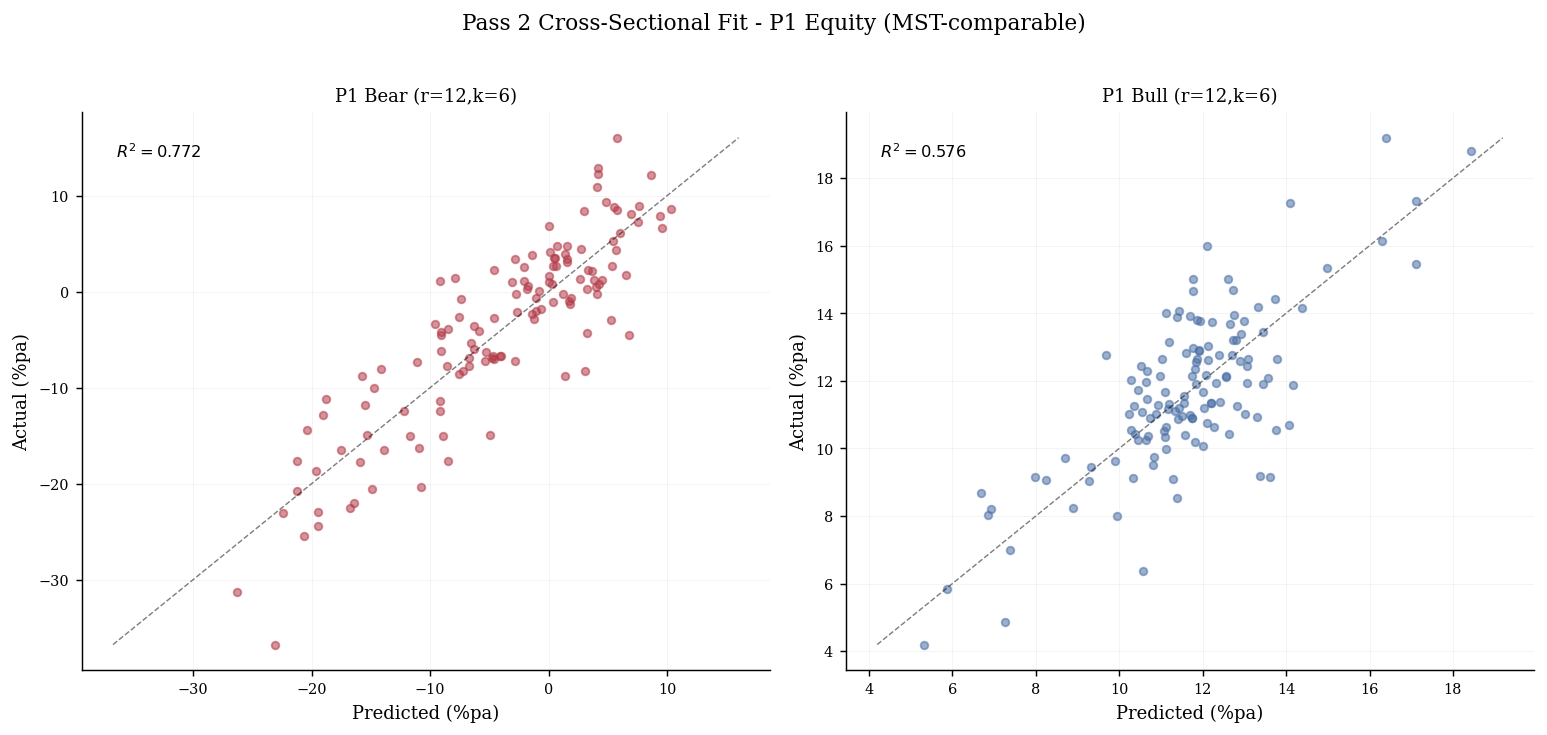

Saved Output/fig_equity_crosssection_p1.png


In [26]:
fig,axes=plt.subplots(1,2,figsize=(12,5.5))
for ax,(pred,actual,col,title) in zip(axes,[
    (p2_p1['predD'],p2_p1['RD'],C_P1,'P1 Bear (r=12,k=6)'),
    (p2_p1['predS'],p2_p1['RS'],C_MST,'P1 Bull (r=12,k=6)'),
]):
    ax.scatter(pred*12,actual*12,color=col,s=18,alpha=0.55)
    lo=min(pred.min(),actual.min())*12; hi=max(pred.max(),actual.max())*12
    ax.plot([lo,hi],[lo,hi],'k--',lw=0.8,alpha=0.5)
    ss_res=((actual-pred)**2).sum(); ss_tot=((actual-actual.mean())**2).sum()
    r2=1-ss_res/(ss_tot+1e-30)
    ax.text(0.05,0.92,f'$R^2={r2:.3f}$',transform=ax.transAxes,fontsize=9)
    ax.set_xlabel('Predicted (%pa)'); ax.set_ylabel('Actual (%pa)')
    ax.set_title(title,fontsize=10); ax.grid(alpha=0.15,lw=0.5)
fig.suptitle('Pass 2 Cross-Sectional Fit - P1 Equity (MST-comparable)',fontsize=12,y=1.02)
plt.tight_layout()
plt.savefig('Output/fig_equity_crosssection_p1.png',bbox_inches='tight',facecolor='white')
plt.show(); print('Saved Output/fig_equity_crosssection_p1.png')

### Figure - Cross-Sectional Fit: MST vs MS P1 vs Unconditional (2x2)

2x2 cross-sectional scatter: conditional vs unconditional per regime classifier.
Left column: y-axis = MST partition means. Right column: y-axis = MS P1 means.
Each column shows: conditional model (colour) vs unconditional (grey).
Shared axis limits across all four panels.

Requires in scope:
  X, d_D, d_S, N_FACTORS, N, T_D, T_S
  B_D, B_S, gamma_D, gamma_S          : MST Pass 2
  B1_p1, B2_p1, xi_bear_p1, xi_bull_p1: MS P1 EM outputs
  B_unc, gamma_unc                     : unconditional model (from import cell)
  mst_demean, mst_gamma, compute_rmspe : native functions
  pipeline_pass2                       : native function


Left column (MST partition y-axis):
  Bear: MST=0.960  MS P1=0.970  Unc=-1.067
  Bull: MST=0.990  MS P1=0.984               Unc=0.705 
Right column (MS P1 partition y-axis):
  Bear: MS P1=0.795  Unc=-1.231
  Bull: MS P1=0.982  Unc=0.896


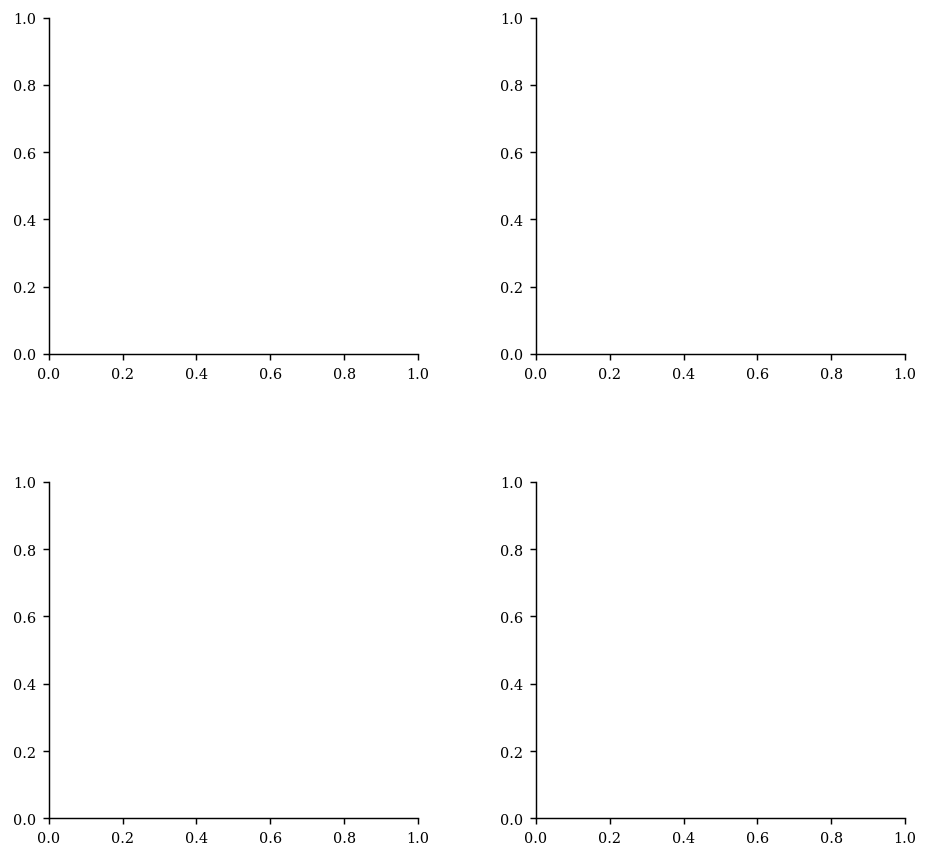

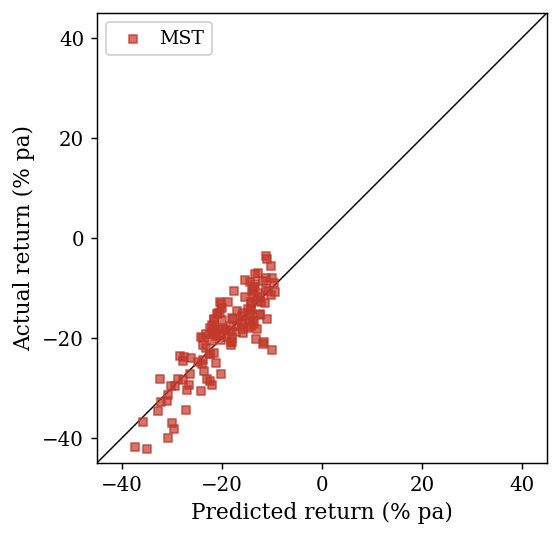

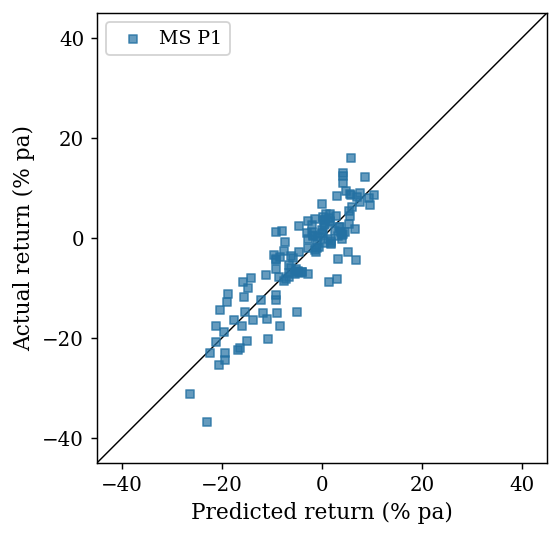

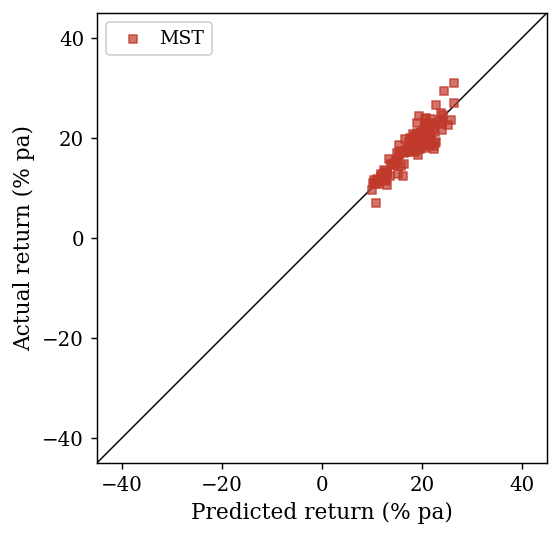

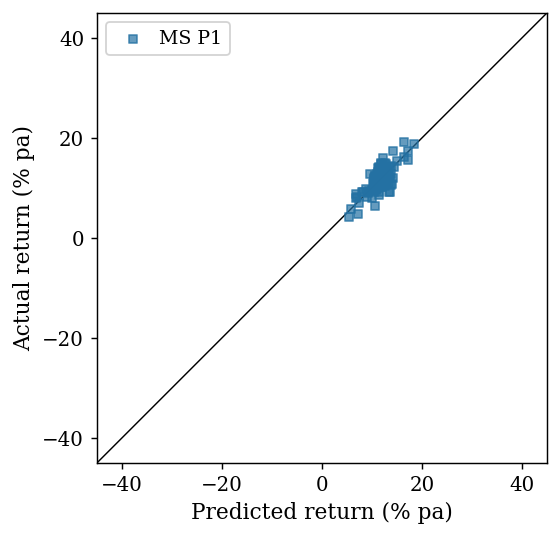

Saved.


In [27]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

k     = N_FACTORS   # 6
scale = 12        # monthly decimal → %pa

# Actual means
_, X_D_mst = mst_demean(X, d_D)   # (N,) MST bear-partition actual means
_, X_S_mst = mst_demean(X, d_S)   # (N,) MST bull-partition actual means

p2         = pipeline_pass2(X, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1, k, N)
X_D_ms     = p2['RD']              # (N,) MS P1 bear actual means (prob-weighted)
X_S_ms     = p2['RS']              # (N,) MS P1 bull actual means

# Conditional predicted returns
# MST: its own predicted returns
pred_mst_D = B_D[:, :k] @ gamma_D[:k]
pred_mst_S = B_S[:, :k] @ gamma_S[:k]

# MS P1 on MST partition (re-estimated gamma using MST months + MS P1 loadings)
def normalise(B, k_):
    cn = np.sqrt((B[:, :k_]**2).sum(0) / N)
    cn = np.where(cn > 1e-10, cn, 1.0)
    return B[:, :k_] / cn[None, :]

B_bear = normalise(B1_p1, k)   # bear loadings after EM permutation
B_bull = normalise(B2_p1, k)   # bull loadings

gamma_ms_D_mst = mst_gamma(X * d_D[:, None], B_bear, k, T_D)
gamma_ms_S_mst = mst_gamma(X * d_S[:, None], B_bull, k, T_S)
pred_ms_D_mst  = B_bear @ gamma_ms_D_mst   # MS P1 scored on MST partition
pred_ms_S_mst  = B_bull @ gamma_ms_S_mst

# MS P1 on its own partition (from pipeline_pass2)
pred_ms_D_own  = p2['predD']
pred_ms_S_own  = p2['predS']

# Unconditional predicted returns (same vector for all panels)
pred_unc = B_unc[:, :k] @ gamma_unc[:k]   # (N,)

# Adjusted R^2
def adjr2(actual, pred, N, k):
    rmspe = np.sqrt(((actual - pred)**2).mean())
    r2    = 1 - N * rmspe**2 / (actual @ actual)
    return 1 - (1 - r2) * N / (N - k)

# Left column (MST partition y-axis)
ar2_mst_D    = adjr2(X_D_mst, pred_mst_D,    N, k)
ar2_mst_S    = adjr2(X_S_mst, pred_mst_S,    N, k)
ar2_ms_D_mst = adjr2(X_D_mst, pred_ms_D_mst, N, k)
ar2_ms_S_mst = adjr2(X_S_mst, pred_ms_S_mst, N, k)
ar2_unc_D_mst= adjr2(X_D_mst, pred_unc,      N, k)
ar2_unc_S_mst= adjr2(X_S_mst, pred_unc,      N, k)

# Right column (MS P1 partition y-axis)
ar2_ms_D_own = adjr2(X_D_ms,  pred_ms_D_own, N, k)
ar2_ms_S_own = adjr2(X_S_ms,  pred_ms_S_own, N, k)
ar2_unc_D_ms = adjr2(X_D_ms,  pred_unc,      N, k)
ar2_unc_S_ms = adjr2(X_S_ms,  pred_unc,      N, k)
ar2_mst_D_ms = adjr2(X_D_ms,  pred_mst_D,    N, k)
ar2_mst_S_ms = adjr2(X_S_ms,  pred_mst_S,    N, k)

print('Left column (MST partition y-axis):')
print(f'  Bear: MST={ar2_mst_D:.3f}  MS P1={ar2_ms_D_mst:.3f}  Unc={ar2_unc_D_mst:.3f}')
print(f'  Bull: MST={ar2_mst_S:.3f}  MS P1={ar2_ms_S_mst:.3f}               Unc={ar2_unc_S_mst:.3f} ')
print('Right column (MS P1 partition y-axis):')
print(f'  Bear: MS P1={ar2_ms_D_own:.3f}  Unc={ar2_unc_D_ms:.3f}')
print(f'  Bull: MS P1={ar2_ms_S_own:.3f}  Unc={ar2_unc_S_ms:.3f}')

# Global axis limits
all_vals = np.concatenate([
    pred_mst_D, pred_mst_S, pred_ms_D_mst, pred_ms_S_mst,
    pred_ms_D_own, pred_ms_S_own, pred_unc,
    X_D_mst, X_S_mst, X_D_ms, X_S_ms
]) * scale
p2_lo = np.percentile(all_vals, 1)
p2_hi = np.percentile(all_vals, 99)
pad   = (p2_hi - p2_lo) * 0.06
g_lo, g_hi = -45, 45

# Plot
C_MST = '#C0392B'
C_MS  = '#2471A3'
C_UNC = '#7F8C8D'
ALPHA_COND = 0.70
ALPHA_UNC  = 0.35
MS_SZ = 18
FONT  = 12

fig, axes = plt.subplots(2, 2, figsize=(8.5, 8.0))
fig.subplots_adjust(hspace=0.38, wspace=0.32)

panels = [
    (X_D_mst, pred_mst_D,    ar2_mst_D,    C_MST, 's', 'MST',   'fig_cs_mst_bear'),
    (X_D_ms,  pred_ms_D_own, ar2_ms_D_own, C_MS,  's', 'MS P1', 'fig_cs_ms_bear'),
    (X_S_mst, pred_mst_S,    ar2_mst_S,    C_MST, 's', 'MST',   'fig_cs_mst_bull'),
    (X_S_ms,  pred_ms_S_own, ar2_ms_S_own, C_MS,  's', 'MS P1', 'fig_cs_ms_bull'),
]

for actual, cond_pred, cond_r2, col, mkr, cond_lbl, fname in panels:
    fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

    a  = actual    * scale
    cp = cond_pred * scale

    ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
    ax.scatter(cp, a, color=col, marker=mkr, s=MS_SZ, alpha=ALPHA_COND,
               zorder=2, label=cond_lbl)

    ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
    ax.set_aspect('equal')
    ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
    ax.set_ylabel('Actual return (% pa)',    fontsize=FONT)
    #ax.set_title(title, fontsize=FONT + 1, fontweight='bold')
    ax.tick_params(labelsize=FONT - 1)
    ax.legend(fontsize=FONT - 1.5, framealpha=0.85,
              loc='upper left', handletextpad=0.4)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    plt.savefig(f'Output/{fname}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'Output/{fname}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

print('Saved.')


### Figure - Conditional (MST) vs Unconditional Fit, Bear and Bull

Two single-panel scatterplots (saved separately): realised vs predicted
returns for the MST conditional model against the unconditional benchmark,
one panel per regime.


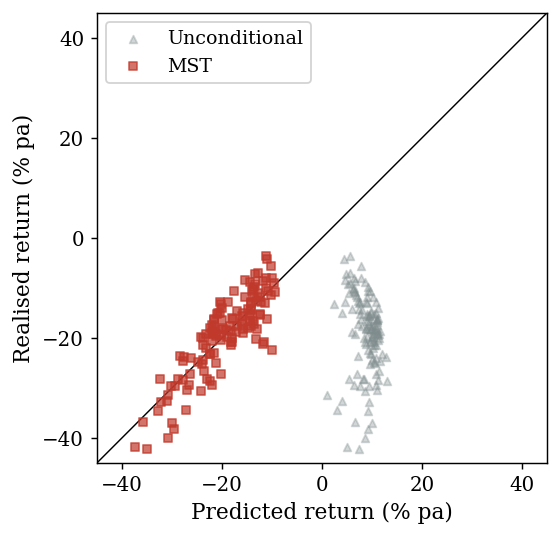

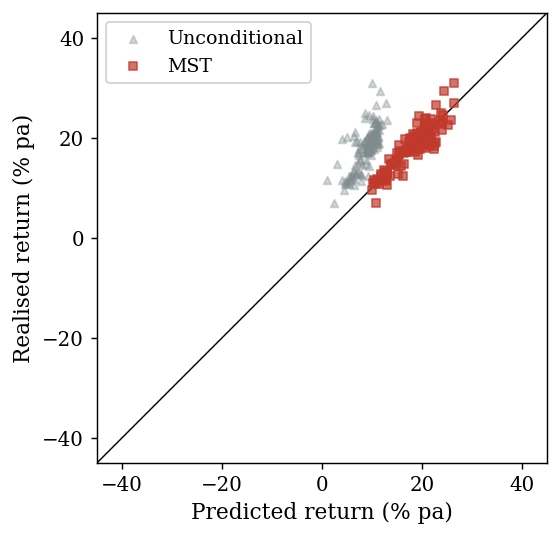

In [28]:
# Bear panel
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

a  = X_D_mst   * scale
cp = pred_mst_D * scale
up = pred_unc   * scale

ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
ax.scatter(up, a, color=C_UNC, marker='^', s=MS_SZ, alpha=ALPHA_UNC,
           zorder=1, label='Unconditional')
ax.scatter(cp, a, color=C_MST, marker='s', s=MS_SZ, alpha=ALPHA_COND,
           zorder=2, label='MST')

ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
ax.set_aspect('equal')
ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
ax.set_ylabel('Realised return (% pa)',    fontsize=FONT)
#ax.set_title('Whole sample, Bear ($D$) regime', fontsize=FONT + 1, fontweight='bold')
ax.tick_params(labelsize=FONT - 1)
ax.legend(fontsize=FONT - 1.5, framealpha=0.85, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.savefig('Output/fig_mst_cond_vs_unc_bear.png', bbox_inches='tight', dpi=300)
plt.savefig('Output/fig_mst_cond_vs_unc_bear.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Bull panel
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))

a  = X_S_mst   * scale
cp = pred_mst_S * scale
up = pred_unc   * scale

ax.plot([g_lo, g_hi], [g_lo, g_hi], 'k-', lw=0.8, zorder=0)
ax.scatter(up, a, color=C_UNC, marker='^', s=MS_SZ, alpha=ALPHA_UNC,
           zorder=1, label='Unconditional')
ax.scatter(cp, a, color=C_MST, marker='s', s=MS_SZ, alpha=ALPHA_COND,
           zorder=2, label='MST')

ax.set_xlim(g_lo, g_hi); ax.set_ylim(g_lo, g_hi)
ax.set_aspect('equal')
ax.set_xlabel('Predicted return (% pa)', fontsize=FONT)
ax.set_ylabel('Realised return (% pa)',    fontsize=FONT)
#ax.set_title('Whole sample, Bull ($S$) regime', fontsize=FONT + 1, fontweight='bold')
ax.tick_params(labelsize=FONT - 1)
ax.legend(fontsize=FONT - 1.5, framealpha=0.85, loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(5))
ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.8)
    spine.set_color('black')

plt.savefig('Output/fig_mst_cond_vs_unc_bull.png', bbox_inches='tight', dpi=300)
plt.savefig('Output/fig_mst_cond_vs_unc_bull.pdf', bbox_inches='tight', dpi=300)
plt.show()

### Figure - Regime Probability Timeline (P1 vs P2)


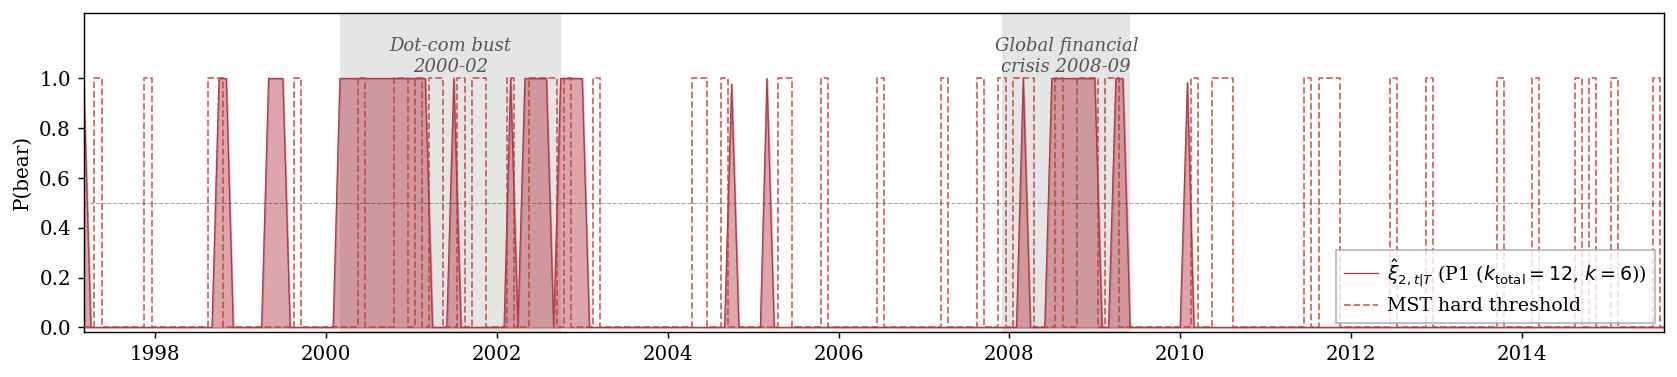

Saved fig6_p1_timeline


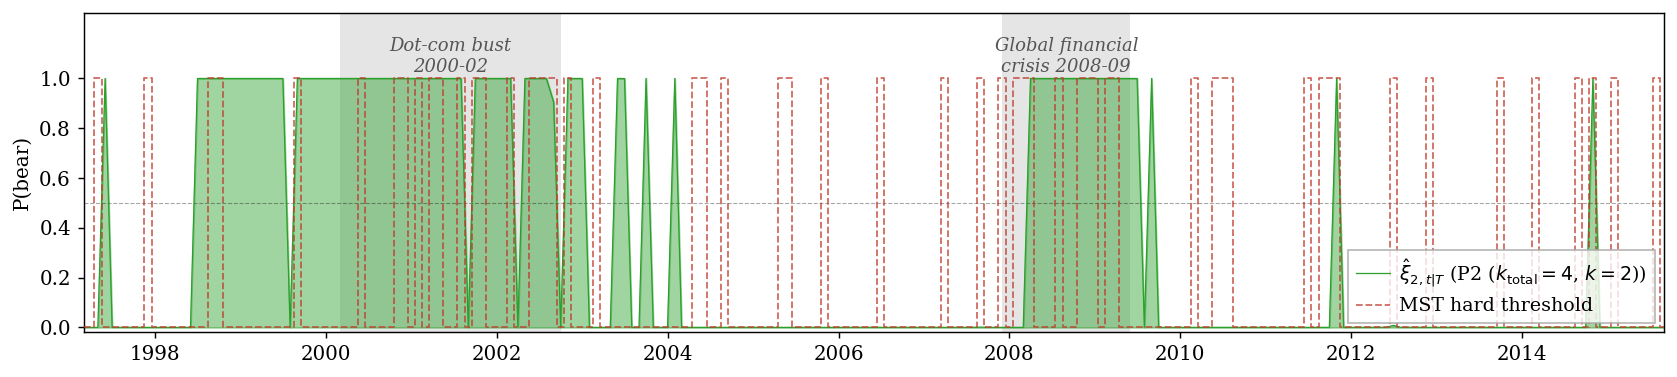

Saved fig6_p2_timeline


In [ ]:
import matplotlib.dates as mdates

for panel_idx, (xi_, label, color, fname) in enumerate([
    (xi_bear_p1, f'P1 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P1}$, $k={K_P1}$)', C_P1, 'fig6_p1_timeline'),
    (xi_bear_p2, f'P2 ($k_{{\\mathrm{{total}}}}={R_TOTAL_P2}$, $k={K_P2}$)', C_P2, 'fig6_p2_timeline'),
]):
    fig, ax = plt.subplots(1, 1, figsize=(13, 3))

    # Crisis shading + centred labels
    for cs, ce, lbl in crisis_windows:
        t_start = pd.Timestamp(cs)
        t_end   = pd.Timestamp(ce)
        t_mid   = t_start + (t_end - t_start) / 2
        ax.axvspan(t_start, t_end, alpha=0.2, color='gray', lw=0, zorder=0)
        ax.text(t_mid, 1.01, lbl, ha='center', va='bottom',
                fontsize=FONT - 2, color='#555', style='italic')

    # Filled probability area
    ax.fill_between(dates, xi_, alpha=0.45, color=color, zorder=1)
    ax.plot(dates, xi_, lw=0.7, color=color,
            label=r'$\hat{\xi}_{2,t|T}$ ' + f'({label})', zorder=2)

    # MST threshold - dashed
    ax.step(dates, bear_mst, where='mid',
            color=C_MST, lw=1.0, alpha=0.75,
            ls='--', label='MST hard threshold', zorder=3)

    # 0.5 decision line
    ax.axhline(0.5, color='black', ls='--', lw=0.6, alpha=0.35, zorder=1)

    n_int = ((xi_ > 0.05) & (xi_ < 0.95)).sum()
    ax.set_ylim(-0.02, 1.263)
    ax.set_ylabel('P(bear)', fontsize=FONT - 1)
    '''
    ax.set_title(
        f'{label}\u2002|\u2002Interior = {n_int}/{T} ({n_int/T:.1%})',
        fontsize=9.5, pad=6
    )
    '''
    ax.tick_params(axis='x', labelsize=FONT - 1)
    ax.tick_params(axis='y', labelsize=FONT - 1)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.set_xlim(dates.min(), dates.max())

    # Box + no grid
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_color('black')

    # Legend - boxed with default (light) edge, not black
    ax.legend(frameon=True, fontsize= FONT - 1.5, loc='lower right',
              fancybox=False, edgecolor='#aaaaaa',
              handlelength=1.8, handletextpad=0.5)

    plt.tight_layout()
    plt.savefig(f'Output/{fname}.pdf', bbox_inches='tight', dpi=300)
    plt.savefig(f'Output/{fname}.png', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()
    print(f'Saved {fname}')

### Paired Bootstrap Test - MS vs MST RMSPE

Paired bootstrap test: H0: RMSPE_j^MS >= RMSPE_j^MST  vs  H1: RMSPE_j^MS < RMSPE_j^MST


In [ ]:
import numpy as np
import time

# CONSTANTS
B_BOOT_PAIRED   = 499
K_TEST          = N_FACTORS   # = 6, matches the conditional MST block above
RNG_SEED_PAIRED = 19780308

# OBSERVED QUANTITIES
# rmspe_mst_D / rmspe_mst_S already computed in the unconditional-model cell.
# MS P1 observed quantities, from the existing P1 pricing run.
p2_obs = pipeline_pass2(X, B1_p1, B2_p1, xi_bear_p1, xi_bull_p1, K_TEST, N)
rmspe_ms_D_obs = p2_obs['rD']
rmspe_ms_S_obs = p2_obs['rS']

delta_D_obs = rmspe_mst_D - rmspe_ms_D_obs   # > 0 means MS wins bear
delta_S_obs = rmspe_mst_S - rmspe_ms_S_obs   # > 0 means MS wins bull

print('='*70)
print('Paired bootstrap: H0: RMSPE_j^MS >= RMSPE_j^MST  (k=N_FACTORS, equity P1)')
print(f'  Observed Delta_D = {delta_D_obs*12:.3f}%pa  '
      f'(MST {rmspe_mst_D*12:.3f} vs MS {rmspe_ms_D_obs*12:.3f})')
print(f'  Observed Delta_S = {delta_S_obs*12:.3f}%pa  '
      f'(MST {rmspe_mst_S*12:.3f} vs MS {rmspe_ms_S_obs*12:.3f})')
print('='*70)

# BOOTSTRAP LOOP
T, N = X.shape
resid_unc = X - F_wm_unc @ B_unc.T            # (T, N), unconditional residuals

rng = np.random.default_rng(RNG_SEED_PAIRED)
count_D = 0
count_S = 0
t0 = time.time()

for b in range(B_BOOT_PAIRED):

    # Step 1 - bootstrap data under H0: unconditional null, no regime imposed.
    w = rng.standard_normal((T, N))
    X_boot = F_wm_unc @ B_unc.T + resid_unc * w

    # Step 2 - re-estimate MST three-pass on X_boot at K_TEST, using this
    # notebook's native mst_demean/mst_pca/mst_gamma (no second copy).
    Xdm_D_b, X_D_mean_b = mst_demean(X_boot, d_D)
    Xdm_S_b, X_S_mean_b = mst_demean(X_boot, d_S)

    B_D_b = mst_pca(Xdm_D_b, K_TEST, N)
    B_S_b = mst_pca(Xdm_S_b, K_TEST, N)

    gamma_D_b = mst_gamma(X_boot * d_D[:, None], B_D_b, K_TEST, T_D)
    gamma_S_b = mst_gamma(X_boot * d_S[:, None], B_S_b, K_TEST, T_S)

    pe_D_b = X_D_mean_b - B_D_b @ gamma_D_b
    pe_S_b = X_S_mean_b - B_S_b @ gamma_S_b
    rmspe_mst_D_b = compute_rmspe(pe_D_b, N)
    rmspe_mst_S_b = compute_rmspe(pe_S_b, N)

    # Step 3 - re-estimate BM EM on X_boot, draw-specific rng.
    draw_rng = np.random.default_rng(RNG_SEED_PAIRED + b + 1)
    (B1_b, B2_b, sig1_b, sig2_b, P_b,
     xi_bear_b, xi_bull_b, best_ll_b, A_hat_b, G_hat_b,
     p11_b, p22_b) = run_em_pipeline(
        X_boot, R_TOTAL_P1, label='', rng=draw_rng, verbose=False
    )
    p2_b = pipeline_pass2(X_boot, B1_b, B2_b, xi_bear_b, xi_bull_b, K_TEST, N)
    rmspe_ms_D_b = p2_b['rD']
    rmspe_ms_S_b = p2_b['rS']

    # Step 4 - bootstrap test statistics
    delta_D_b = rmspe_mst_D_b - rmspe_ms_D_b
    delta_S_b = rmspe_mst_S_b - rmspe_ms_S_b

    # Step 5 - accumulate one-sided exceedances
    if delta_D_b >= delta_D_obs:
        count_D += 1
    if delta_S_b >= delta_S_obs:
        count_S += 1

    if (b + 1) % 25 == 0:
        elapsed = time.time() - t0
        eta_min = elapsed / (b+1) * (B_BOOT_PAIRED - b - 1) / 60
        print(f'  b={b+1}/{B_BOOT_PAIRED}  '
              f'running p_D={count_D/(b+1):.3f}  p_S={count_S/(b+1):.3f}  '
              f'elapsed={elapsed/60:.1f}min  ETA={eta_min:.1f}min')

# RESULTS
p_D = count_D / B_BOOT_PAIRED
p_S = count_S / B_BOOT_PAIRED

def sig(p):
    if p < 0.01: return '***'
    if p < 0.05: return '**'
    if p < 0.10: return '*'
    return ''

print()
print('='*70)
print(f'Paired bootstrap results (B={B_BOOT_PAIRED}, k=N_FACTORS, equity P1)')
print(f'  Bear (D): Delta={delta_D_obs*12:.3f}%pa  p={p_D:.3f}{sig(p_D)}')
print(f'  Bull (S): Delta={delta_S_obs*12:.3f}%pa  p={p_S:.3f}{sig(p_S)}')
print('='*70)
print('Null DGP: full-sample unconditional factor residuals (no regime imposed).')
print(f'Total runtime: {(time.time()-t0)/60:.1f} minutes.')


Paired bootstrap: H0: RMSPE_j^MS >= RMSPE_j^MST  (k=N_FACTORS, commodity P1)
  Observed Delta_D = -0.556%pa  (MST 4.080 vs MS 4.636)
  Observed Delta_S = 0.281%pa  (MST 1.833 vs MS 1.552)

[] r_total=12, PVE=96.0%
  Start        final_ll      p11      p22   xi2_mean
  --------------------------------------------------
      1     -1.48023293   0.8467   0.6665     0.3229
      2     -1.48126162   0.7434   0.7247     0.4887
      3     -1.47867359   0.7820   0.7378     0.4615
      4     -1.56708183   0.8000   0.8000     0.5000
      5     -1.48288990   0.8389   0.6849     0.3318
      6     -1.48071496   0.8152   0.7010     0.3899
      7     -1.48071496   0.8152   0.7010     0.3899
      8     -1.56708183   0.7500   0.7500     0.5000
      9     -1.47793739   0.9078   0.8269     0.3632
     10     -1.56708183   0.6000   0.6000     0.5000
     11     -1.48781185   0.9249   0.7143     0.2197
     12     -1.48183565   0.7412   0.7069     0.4750
     13     -1.48033768   0.8355   0.6285   

---
## Save Outputs

In [ ]:
pd.DataFrame({
    'date': dates.dt.strftime('%Y-%m'),
    'xi_bear_p1': xi_bear_p1, 'xi_bull_p1': xi_bull_p1,
    'xi_bear_p2': xi_bear_p2, 'xi_bull_p2': xi_bull_p2,
    'bear_p1': bear_p1, 'bear_p2': bear_p2, 'bear_mst': bear_mst,
    'adbear': adb,
}).to_csv('Output/ms_equity_smoothed_probs.csv', index=False)

df_p1.to_csv('Output/ms_equity_pricing_p1.csv')
df_p2.to_csv('Output/ms_equity_pricing_p2.csv')

print('Saved:')
print('  Output/ms_equity_smoothed_probs.csv')
print('  Output/ms_equity_pricing_p1.csv')
print('  Output/ms_equity_pricing_p2.csv')

Saved:
  Output/ms_equity_smoothed_probs.csv
  Output/ms_equity_pricing_p1.csv
  Output/ms_equity_pricing_p2.csv
